# NFL Big Data Bowl 2026 — Trajectory Prediction with a Temporal Graph Attention Network

Given the tracking data of all the players until the ball is thrown, the task is to predict the `(x, y)` trajectory of the players to predict while the ball is in the air. Each play is turned into a spatio-temporal graph (nodes are player-frames, edges link nearby players in the same frame and the same player in consecutive frames), encoded with a temporal graph attention network (TGAT), enriched with the context of the play, and decoded in one shot into the whole trajectory.

The notebook keeps the code of the contributions (ball and global features, model, loss, experiments). Loading, analysis, dataset construction, training loop and plots live in the `nfl_bdb` package of the GitHub repository [GioPonzu/NFL-BDB-26](https://github.com/GioPonzu/NFL-BDB-26): the notebook clones it and shows the output of its functions where needed.

## Index

1. Configuration
2. Data Loading and Preprocessing
3. Players Physique Inspection
4. Plays: Retrieval, Standardization and Visualization
5. Play Features
6. Model Inputs
7. Data Pipeline
8. Model
9. Training and Baseline
10. Ablation Studies
11. Results

---
# 1. Configuration

Libraries, repository, hardware, reproducibility and every parameter of the pipeline: what is set here is used, unchanged, by all the following chapters.

## 1.1 Repository and Dependencies

The support code lives in the `nfl_bdb` package of the repository. The first cell clones it and makes it importable; the second one installs `torch_geometric` (not preinstalled in Colab), imports the libraries and the functions of the package used in the notebook.

In [1]:
import os
import subprocess
import sys

REPO_URL = "https://github.com/GioPonzu/NFL-BDB-26"
REPO_DIR = os.path.abspath("NFL-BDB-26")
BRANCH = "no_run_plots"   # the ablation grid is now complete on "no_run_plots" -- set back to that branch name here
                          # only if you need to re-test something on it before it is merged

if not os.path.isdir(REPO_DIR):
    clone_cmd = ["git", "clone", "--depth", "1"]
    if BRANCH:
        clone_cmd += ["--branch", BRANCH]
    clone_cmd += [REPO_URL, REPO_DIR]
    subprocess.run(clone_cmd, check=True)
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)   # so outputs/, weights/ (both relative paths in Config) resolve inside the repo, not /content

In [2]:
!pip install torch_geometric --quiet
import torch_geometric
print(f"torch_geometric version: {torch_geometric.__version__}")

from pathlib import Path
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Batch
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax

from nfl_bdb import Config, fix_random
from nfl_bdb.data import (load_raw_data, sanitize_positions, apply_play_filter, build_players_df, preprocess_players,
                          get_play, standardize_plays)
from nfl_bdb.analysis import (plot_players_to_predict, plot_frames_per_play, physique_summary, plot_physique_kde,
                              report_length_bins, check_splits)
from nfl_bdb.features import (get_play_stats, get_predicted_players_df, preprocess_play, get_node_features,
                              pack_play_features, get_edge_features, preprocess_aux)
from nfl_bdb.dataset import compute_play_lengths, make_splits, BatchProvider
from nfl_bdb.utils import get_device
from nfl_bdb.training import ExperimentRunner, run_stage
from nfl_bdb.viz import visualize_play, show_predictions
from nfl_bdb.results import (STUDIES, load_all_results, show_summary_table, print_takeaways, plot_ablations,
                             plot_learning_curves, plot_run, global_feature_names, global_branch_diagnostics)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.1 MB/s eta 0:00:00
torch_geometric version: 2.8.0.post1


## 1.2 Data Source

The competition files are downloaded with `kagglehub` (a Kaggle login is required): the tracking data (weekly `input`/`output` files, before and after the throw) and the analytics dataset with the supplementary play context.

In [3]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
nfl_big_data_bowl_2026_prediction_path = kagglehub.competition_download('nfl-big-data-bowl-2026-prediction')
nfl_big_data_bowl_2026_analytics_path = kagglehub.competition_download('nfl-big-data-bowl-2026-analytics')

print('Data source import complete.')

100%|██████████| 102M/102M [00:00<00:00, 117MB/s]

Extracting files...


100%|██████████| 103M/103M [00:00<00:00, 138MB/s]

Extracting files...


Data source import complete.


## 1.3 Runtime Settings

The model is too slow to train on CPU, so a GPU runtime (T4 in Colab) is expected. The cell only reports what is available and stores the device used by all the following chapters.

In [5]:
device = get_device()

All good, a GPU is available.


## 1.4 Parameters and Hyperparameters

Every parameter of the pipeline is set in one `Config` object, so what a run uses is visible here and nowhere else. The values below are the ones of the reported experiments.

| Group | Parameters | Meaning |
| --- | --- | --- |
| Data | `DATA_PATH`, `AUXILIARY_DATA_PATH`, `WEEKS`, `FRAME_RATE` | Location of the files, weeks used, frames per second |
| Padding | `MAX_INPUT_NODES/FRAMES`, `MAX_OUTPUT_NODES/FRAMES` | Upper bounds of the padded tensors (players and frames before and after the throw) |
| Graph | `K` | Spatial neighbours per node (a play needs at least `K + 1` players in every frame) |
| Model | `HIDDEN_DIM`, `NODE_IN_DIM`, `EDGE_IN_DIM`, `GAT_NUM_LAYERS`, `REGRESSOR_HIDDEN_DIM` | Hidden size of the baseline model, size of node and edge features, depth of each GAT branch and width of the final regressor |
| Split | `N_TRAIN/N_VAL/N_TEST`, `N_LENGTH_BINS` | Plays per split and bins used to stratify by play length |
| Training | `NUM_EPOCHS`, `BATCH_SIZE`, `LEARNING_RATE`, `GRAD_CLIP_NORM`, `EARLY_STOP_PATIENCE` | Optimization of the baseline run |
| Plateau logic | `PLATEAU_THRESHOLD(_MODE)`, `SCHEDULER_*` | What counts as an improvement, shared by the LR scheduler and early stopping |
| Loss | `W_FDE`, `W_SMOOTH` | Weights of the final-position and smoothness terms (Chapter 9) |

In [6]:
cfg = Config(
    # Data
    DATA_PATH = Path(nfl_big_data_bowl_2026_prediction_path) / "train",
    AUXILIARY_DATA_PATH = Path(nfl_big_data_bowl_2026_analytics_path) / "114239_nfl_competition_files_published_analytics_final/supplementary_data.csv",
    WEEKS = list(range(1, 19)),
    FRAME_RATE = 10,

    # Padding limits and graph
    MAX_INPUT_NODES = 17,
    MAX_INPUT_FRAMES = 123,
    MAX_OUTPUT_NODES = 17,
    MAX_OUTPUT_FRAMES = 94,
    K = 5,

    # Model -- new baseline for the second ablation round: 1 GAT layer (deep stacks were much slower to train for a
    # negligible parameter increase), hidden_dim 64 (compensates the extra capacity lost by going back to 1 layer),
    # regressor width 256 (new baseline, see Chapter 10.5).
    HIDDEN_DIM = 64,
    NODE_IN_DIM = 36,
    EDGE_IN_DIM = 7,
    GAT_NUM_LAYERS = 1,
    REGRESSOR_HIDDEN_DIM = 256,

    # Split
    N_TRAIN = 3000, N_VAL = 1000, N_TEST = 1000,
    N_LENGTH_BINS = 15,

    # Training
    NUM_EPOCHS = 100,
    EARLY_STOP_PATIENCE = 20,
    BATCH_SIZE = 1,
    LEARNING_RATE = 2e-3,
    GRAD_CLIP_NORM = 1.0,

    # Plateau logic (LR scheduler and early stopping)
    PLATEAU_THRESHOLD = 0.01,
    PLATEAU_THRESHOLD_MODE = "rel",
    SCHEDULER_FACTOR = 0.5,
    SCHEDULER_PATIENCE = 6,
    SCHEDULER_COOLDOWN = 1,
    SCHEDULER_MIN_LR = 1e-7,

    # Loss
    W_FDE = 2.0,
    W_SMOOTH = 0.5,

    RANDOM_SEED = 42,
    OUTPUT_DIR = Path("outputs"),      # checkpoints and results of the runs (gitignored, ephemeral)
    WEIGHTS_DIR = Path("weights"),     # every run's best checkpoint is ALSO copied here (persisted in the repo)
)

## 1.5 Reproducibility

`fix_random` seeds NumPy and PyTorch (CPU and GPU) and disables the non-deterministic cuDNN modes. The seed is set again at the start of every training run, so runs differ only in the factor under study. Some GPU operations (scatter-add in the graph layers) stay non-deterministic, so repeated runs can differ slightly.

In [7]:
fix_random(seed=cfg.RANDOM_SEED)

---
# 2. Data Loading and Preprocessing

The raw tracking data is loaded, the roles are made consistent and the plays that the model cannot use are removed.

## 2.1 Import Dataset

`load_raw_data` reads in parallel the weekly files of the pre-pass (`input`) and post-pass (`output`) tracking data and the supplementary file, restricted to the plays that have output data. All the tables travel in one `NFLData` object (`data`). The output reports the size of each table.

In [8]:
data = load_raw_data(cfg)

Loading weeks: 100%|██████████| 18/18 [00:05<00:00,  3.35it/s]



Input Data loaded: 4880579 rows, 272 games
Output Data loaded: 562936 rows, 272 games
Auxiliary Data loaded: 18009 rows, 349 games


## 2.2 Data Uniformation and Sanitization

* Role uniformization

`LB`/`MLB` appear as distinct labels in the dataset but refer to the same inside linebacker role, so they are unified into a single `ILB` category, consistent with `OLB`/`DE`/`DT` in the rest of the defense. `T` alone is ambiguous, while `OT` unambiguously identifies the offensive tackle and distinguishes it positionally from the defensive side.

* Individual role corrections

Identified by inspecting the `value_counts` of `player_position`: a few players were annotated with isolated/outlier roles relative to the standard categories for their actual position, and were corrected based on their physical characteristics and on-field usage: `nfl_id` 52991 and 56275 to `FS`, `nfl_id` 46162 to `SS`. `nfl_id` 45244 (Taysom Hill) is annotated as `QB`, but plays predominantly at tight end with occasional snaps at quarterback; the `TE` role is physically more representative of his usage, so it is used instead.

* Play validity filter

Every play must have at least one player with role `Passer` (required by the ball and target features) and at least `K + 1` players in every frame (required by the KNN spatial edges). `cfg.MIN_INPUT_NODES = K + 1` is derived from `K`, the same neighbour count used later to build the graphs, so the filter always stays consistent with the hyperparameter actually used.

The output reports how many plays are valid and how many were dropped, and why.

In [9]:
sanitize_positions(data.input_df)
data = apply_play_filter(data, min_players=cfg.MIN_INPUT_NODES)

Valid plays: 14104 | dropped: 4 (no Passer: 3, < 6 players/frame: 2)
          game_id  play_id  min_players_in_play  has_passer  is_valid
122    2023091001     3216                   11       False     False
8989   2023112603     3503                    5        True     False
9136   2023112606     4180                    1       False     False
10650  2023121009     3594                   11       False     False

Total valid plays after filtering: 14104


## 2.3 Data Inspection

**Players to predict per play.** Each play asks for the trajectory of a subset of the players (`player_to_predict`). The bar chart shows the share of plays for each number of players to predict, that is how many targets the loss sees in a play.

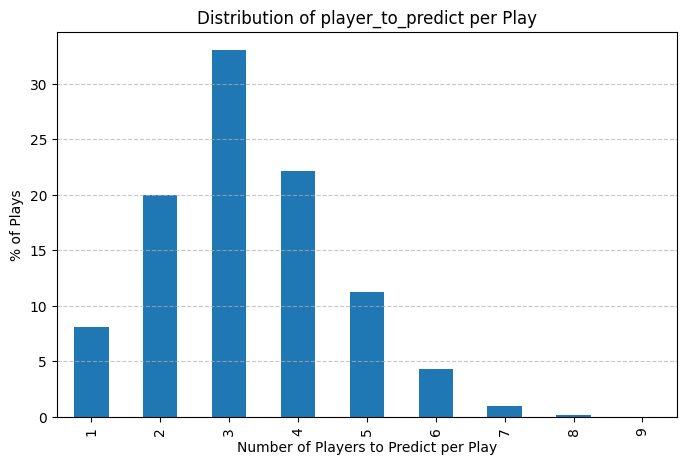

In [10]:
plot_players_to_predict(data.input_df)

**Frames per play.** Histograms of the number of frames before the throw (input) and after it (output, to predict) for each play; the dashed line is the median. Both lengths vary a lot from play to play, which is why the pipeline needs padding and masks (Chapter 7).

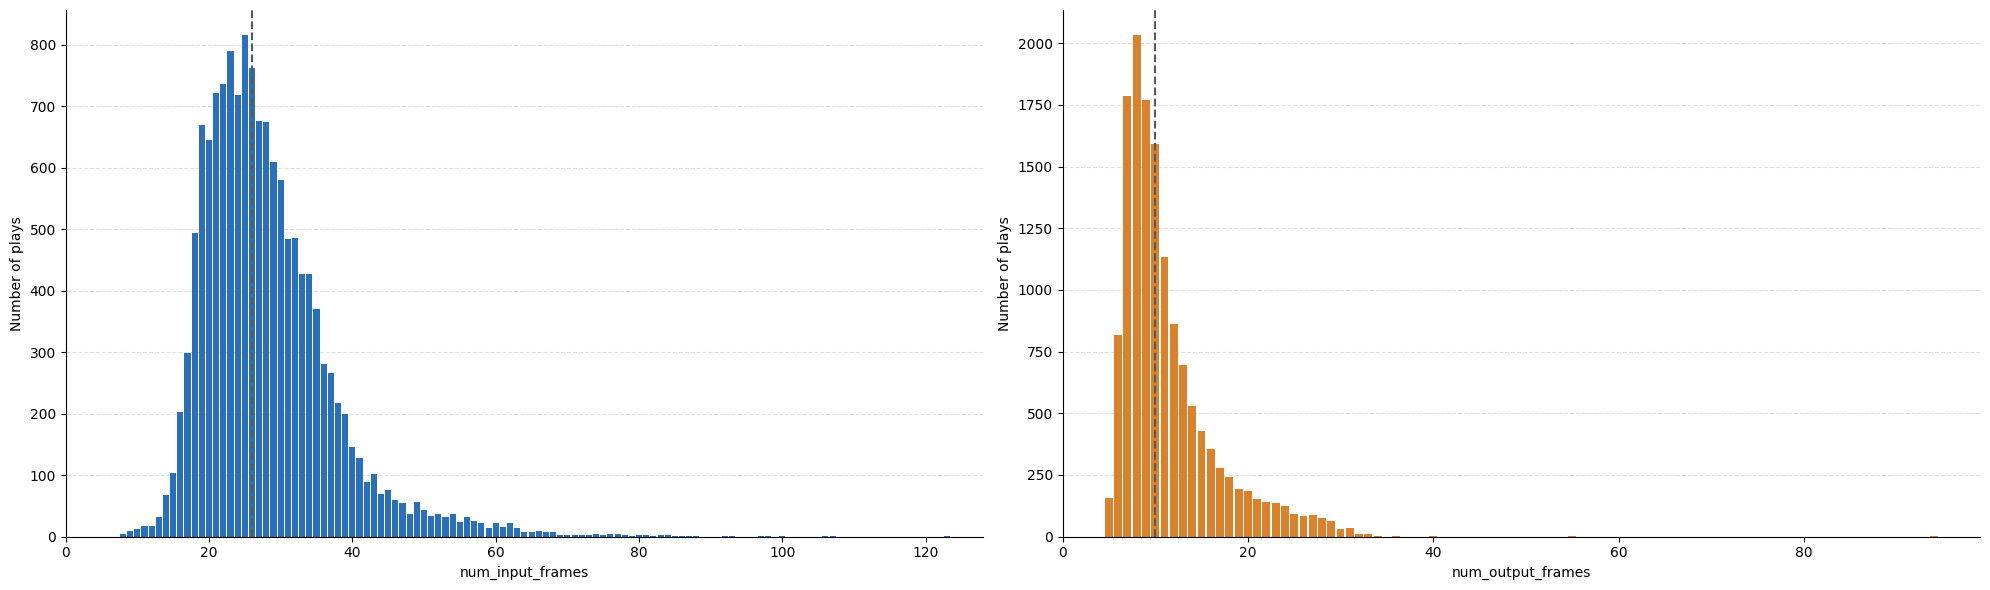

In [11]:
plot_frames_per_play(data.input_df, data.output_df)

---
# 3. Players Physique Inspection

In this chapter we build a table of the core physical attributes of each player, to analyze how physique affects on-field capabilities. In football, physical traits heavily dictate position dynamics: a defensive lineman carries significantly more mass to control the line of scrimmage, resulting in a drastically different mobility profile compared to a wide receiver.

To understand these differences, we run an exploratory inspection grouped by position. This establishes baseline profiles for each role while accounting for the individual variance among players in the same position.

## 3.1 Standard Units Conversion

One row per player with age, height (m), weight (kg) and BMI. The age is computed at the mean date of the 2023 season (15 November 2023), so it does not depend on when the notebook is run. The output shows the first rows of the table.

In [12]:
data.players_df = build_players_df(data.input_df, ref_date="2023-11-15")
data.players_df.head()

,player_name,player_position,player_side,player_age,player_height_m,player_weight_kg,player_BMI
nfl_id,,,,,,,
54514,Alontae Taylor,CB,Defense,24.950034,1.8288,88.450512,26.446483
38607,Demario Davis,ILB,Defense,34.841889,1.8796,112.490908,31.840989
44851,Marcus Maye,FS,Defense,30.685832,1.8288,93.893621,28.073959
44823,Marshon Lattimore,CB,Defense,27.488022,1.8288,87.089735,26.039614
53505,Paulson Adebo,CB,Defense,24.369610,1.8288,87.543327,26.175237


## 3.2 Position Aggregation Physical Inspection

**Summary.** Mean, standard deviation, minimum and maximum of each attribute for each position.

In [13]:
physique_summary(data.players_df)

player_age                                 player_height_m  \
                      mean       std        min        max            mean   
player_position                                                              
CB               25.942429  2.615588  21.382615  33.776865        1.827624   
DE               26.791939  3.059477  21.806982  35.616701        1.933944   
DT               27.536968  2.954971  22.108145  37.204654        1.907592   
FB               28.150034  2.680231  23.529090  32.563997        1.859280   
FS               27.043192  3.021968  22.094456  34.781656        1.831419   
ILB              26.623947  2.496945  21.555099  34.841889        1.869524   
K                39.263518  0.000000  39.263518  39.263518        1.778000   
NT               28.745893  2.200980  24.084873  32.520192        1.893887   
OLB              26.487760  3.042409  21.199179  36.038330        1.908735   
OT               29.774127  0.878923  29.152635  30.395619        2.019300   
P                25.815195  0.000000  25.815195  25.815195        1.879600   
QB               28.291257  3.970914  21.483915  38.828200        1.895642   
RB               25.778100  2.534616  21.111567  33.823409        1.804737   
SS               26.260960  2.759417  22.045175  35.597536        1.841500   
TE               26.716487  3.011176  22.245038  39.490760        1.946371   
WR               26.349293  2.743930  21.524983  34.765229        1.848605   

                                          player_weight_kg            \
                      std     min     max             mean       std   
player_position                                                        
CB               0.041195  1.7272  1.9304        87.335431  4.155358   
DE               0.032402  1.8288  2.0066       122.190400  7.754789   
DT               0.045568  1.8288  2.0320       137.679170  7.370645   
FB               0.033532  1.8034  1.9050       111.946597  8.755625   
FS               0.042039  1.7272  1.9304        92.051194  3.953684   
ILB              0.033033  1.8034  1.9558       106.046897  3.946913   
K                0.000000  1.7780  1.7780        91.172066  0.000000   
NT               0.037063  1.8034  1.9304       145.631500  7.459664   
OLB              0.040372  1.8034  2.0066       112.834437  7.916068   
OT               0.053882  1.9812  2.0574       150.365871  4.169597   
P                0.000000  1.8796  1.8796        88.904105  0.000000   
QB               0.041028  1.7780  1.9812        99.557557  4.677939   
RB               0.043358  1.6764  1.9050        96.795930  6.100402   
SS               0.037674  1.7780  1.9304        92.180713  3.425427   
TE               0.033569  1.8288  2.0320       113.016663  4.675004   
WR               0.062514  1.6764  1.9812        90.182955  7.111989   

                                        player_BMI                       \
                        min         max       mean       std        min   
player_position                                                           
CB                77.110703   98.429544  26.161904  1.284238  21.826484   
DE               102.058283  149.685482  32.682321  2.132331  28.459555   
DT               123.377125  162.386068  37.898069  2.701212  31.432434   
FB               105.687022  141.067227  32.368167  2.067592  29.372685   
FS                80.739442  100.697506  27.455218  1.098509  24.953127   
ILB               94.800805  116.119647  30.363469  1.426018  26.833737   
K                 91.172066   91.172066  28.840201  0.000000  28.840201   
NT               137.438488  157.396552  40.624485  2.253107  37.872015   
OLB               96.615175  140.613635  30.960531  1.801065  27.604083   
OT               147.417520  153.314221  36.943033  2.993025  34.826644   
P                 88.904105   88.904105  25.164653  0.000000  25.164653   
QB                87.996920  111.130131  27.710043  1.110998  25.196573   
RB                79.832257  115.666054

**Distributions.** Density of each attribute, one curve per position. Positions occupy clearly different regions of the plots, which motivates giving the model the physical attributes both as a global and as a within-position score (next section).

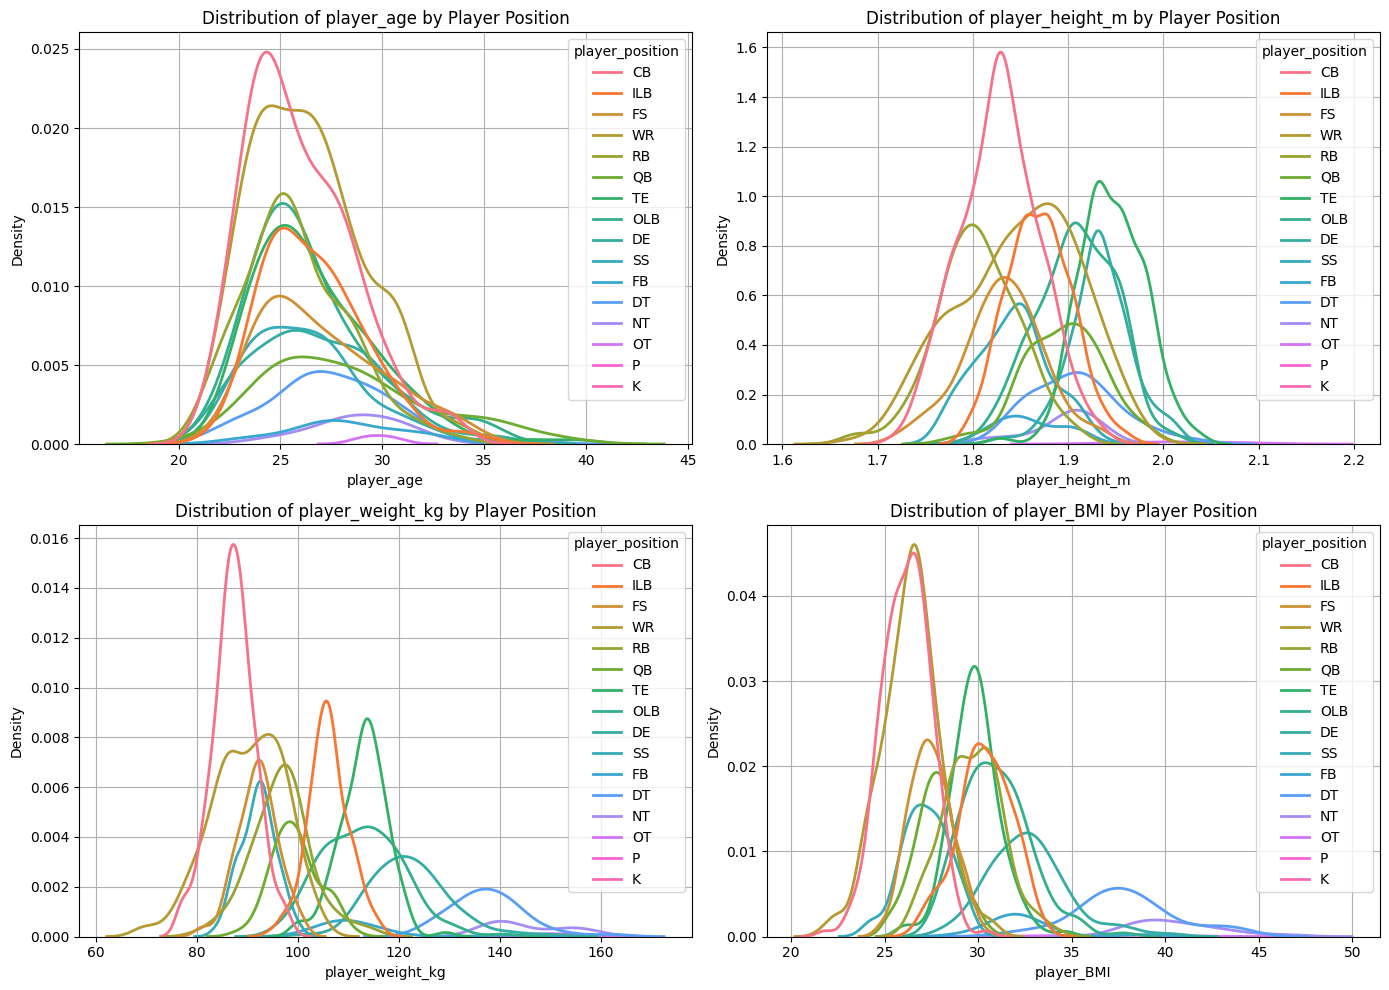

In [14]:
plot_physique_kde(data.players_df)

## 3.3 Data Preprocessing of Player Physique Inspection

Each attribute is normalized twice: a global z-score (compared to all players) and a z-score within the position (compared to players of the same role). Side and position are one-hot encoded. The output is the model-ready table, one row per player; it is merged into the node features in Chapter 6.

In [15]:
data.preprocessed_players_df = preprocess_players(data.players_df)
print(data.preprocessed_players_df.shape)
data.preprocessed_players_df.head()

(1384, 30)


,player_age,player_height_m,player_weight_kg,player_BMI,player_age_global_norm,player_height_m_global_norm,player_weight_kg_global_norm,player_BMI_global_norm,player_age_position_norm,player_height_m_position_norm,player_weight_kg_position_norm,player_BMI_position_norm,player_side_Defense,player_side_Offense,player_position_CB,player_position_DE,player_position_DT,player_position_FB,player_position_FS,player_position_ILB,player_position_K,player_position_NT,player_position_OLB,player_position_OT,player_position_P,player_position_QB,player_position_RB,player_position_SS,player_position_TE,player_position_WR
nfl_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
54514,24.950034,1.8288,88.450512,26.446483,-0.554935,-0.618793,-0.869838,-0.769632,-0.380297,0.028612,0.268971,0.222109,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
38607,34.841889,1.8796,112.490908,31.840989,2.803272,0.195284,0.725989,0.834633,3.304883,0.306298,1.639460,1.040424,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
44851,30.685832,1.8288,93.893621,28.073959,1.392323,-0.618793,-0.508519,-0.285639,1.211649,-0.062613,0.468423,0.566182,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
44823,27.488022,1.8288,87.089735,26.039614,0.306692,-0.618793,-0.960168,-0.890631,0.592289,0.028612,-0.059265,-0.095445,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
53505,24.369610,1.8288,87.543327,26.175237,-0.751985,-0.618793,-0.930058,-0.850298,-0.602722,0.028612,0.050147,0.010407,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


---
# 4. Plays: Retrieval, Standardization and Visualization

## 4.1 Play Retrieval

`get_play(data, game_id, play_id)` returns the pre-pass and post-pass rows of a play. The frames after the throw are renumbered to continue after the last pre-pass frame, so the two tables describe one timeline. The example play used in the following chapters is defined here; the output shows the first rows of both tables.

In [16]:
EXAMPLE_GAME, EXAMPLE_PLAY = 2023101900, 78

prepass_df, postpass_df = get_play(data, EXAMPLE_GAME, EXAMPLE_PLAY)
display(prepass_df.head())
display(postpass_df.head())

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,player_birth_date,player_position,player_side,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023101900,78,False,54514,1,right,35,Alontae Taylor,6-0,195,1998-12-03,CB,Defense,Defensive Coverage,38.30,18.62,0.14,0.17,210.10,277.45,12,44.080002,47.619999
1,2023101900,78,False,54514,2,right,35,Alontae Taylor,6-0,195,1998-12-03,CB,Defense,Defensive Coverage,38.31,18.58,0.30,0.25,183.01,278.61,12,44.080002,47.619999
2,2023101900,78,False,54514,3,right,35,Alontae Taylor,6-0,195,1998-12-03,CB,Defense,Defensive Coverage,38.32,18.54,0.36,0.16,172.37,278.61,12,44.080002,47.619999
3,2023101900,78,False,54514,4,right,35,Alontae Taylor,6-0,195,1998-12-03,CB,Defense,Defensive Coverage,38.35,18.55,0.26,0.05,146.71,278.61,12,44.080002,47.619999
4,2023101900,78,False,54514,5,right,35,Alontae Taylor,6-0,195,1998-12-03,CB,Defense,Defensive Coverage,38.38,18.54,0.27,0.05,128.83,278.61,12,44.080002,47.619999


,game_id,play_id,nfl_id,frame_id,x,y
0,2023101900,78,44851,23,45.00,39.84
1,2023101900,78,44851,24,44.95,40.28
2,2023101900,78,44851,25,44.86,40.74
3,2023101900,78,44851,26,44.74,41.24
4,2023101900,78,44851,27,44.59,41.77


## 4.2 Play Direction Standardization

`standardize_plays(input_df, output_df)` mirrors the plays that go left, so that all of them move toward the right: coordinates, ball landing point, line of scrimmage and the angles `o` and `dir`. It takes the pre-pass data (`input_df`, which contains `play_direction`) and the post-pass data (`output_df`), and returns both standardized. The output compares two rows of a left-going play before and after: `x`, `y`, `o` and `dir` are reflected.

In [17]:
cols = ["game_id", "play_id", "frame_id", "nfl_id", "x", "y", "o", "dir"]
left_rows = data.input_df.loc[data.input_df["play_direction"].str.lower() == "left"].iloc[:2]
print("Before:")
display(left_rows[cols])

data.input_df, data.output_df = standardize_plays(data.input_df, data.output_df)
print("After:")
display(data.input_df.loc[left_rows.index, cols])

Before:


,game_id,play_id,frame_id,nfl_id,x,y,o,dir
833,2023101900,340,1,53494,71.30,19.93,98.97,209.83
834,2023101900,340,2,53494,71.19,19.75,98.97,212.66


After:


,game_id,play_id,frame_id,nfl_id,x,y,o,dir
833,2023101900,340,1,53494,48.70,33.37,278.97,29.83
834,2023101900,340,2,53494,48.81,33.55,278.97,32.66


## 4.3 Play Visualization

Frame-by-frame view of the example play (one frame every 10). Solid trails are the observed pre-pass frames, dashed trails the post-pass frames; blue is the offense (light blue the passer, dark blue the targeted receiver), red the defense and the orange dot is the point where the ball lands. The arrows show the movement direction, with length proportional to speed plus half the acceleration.

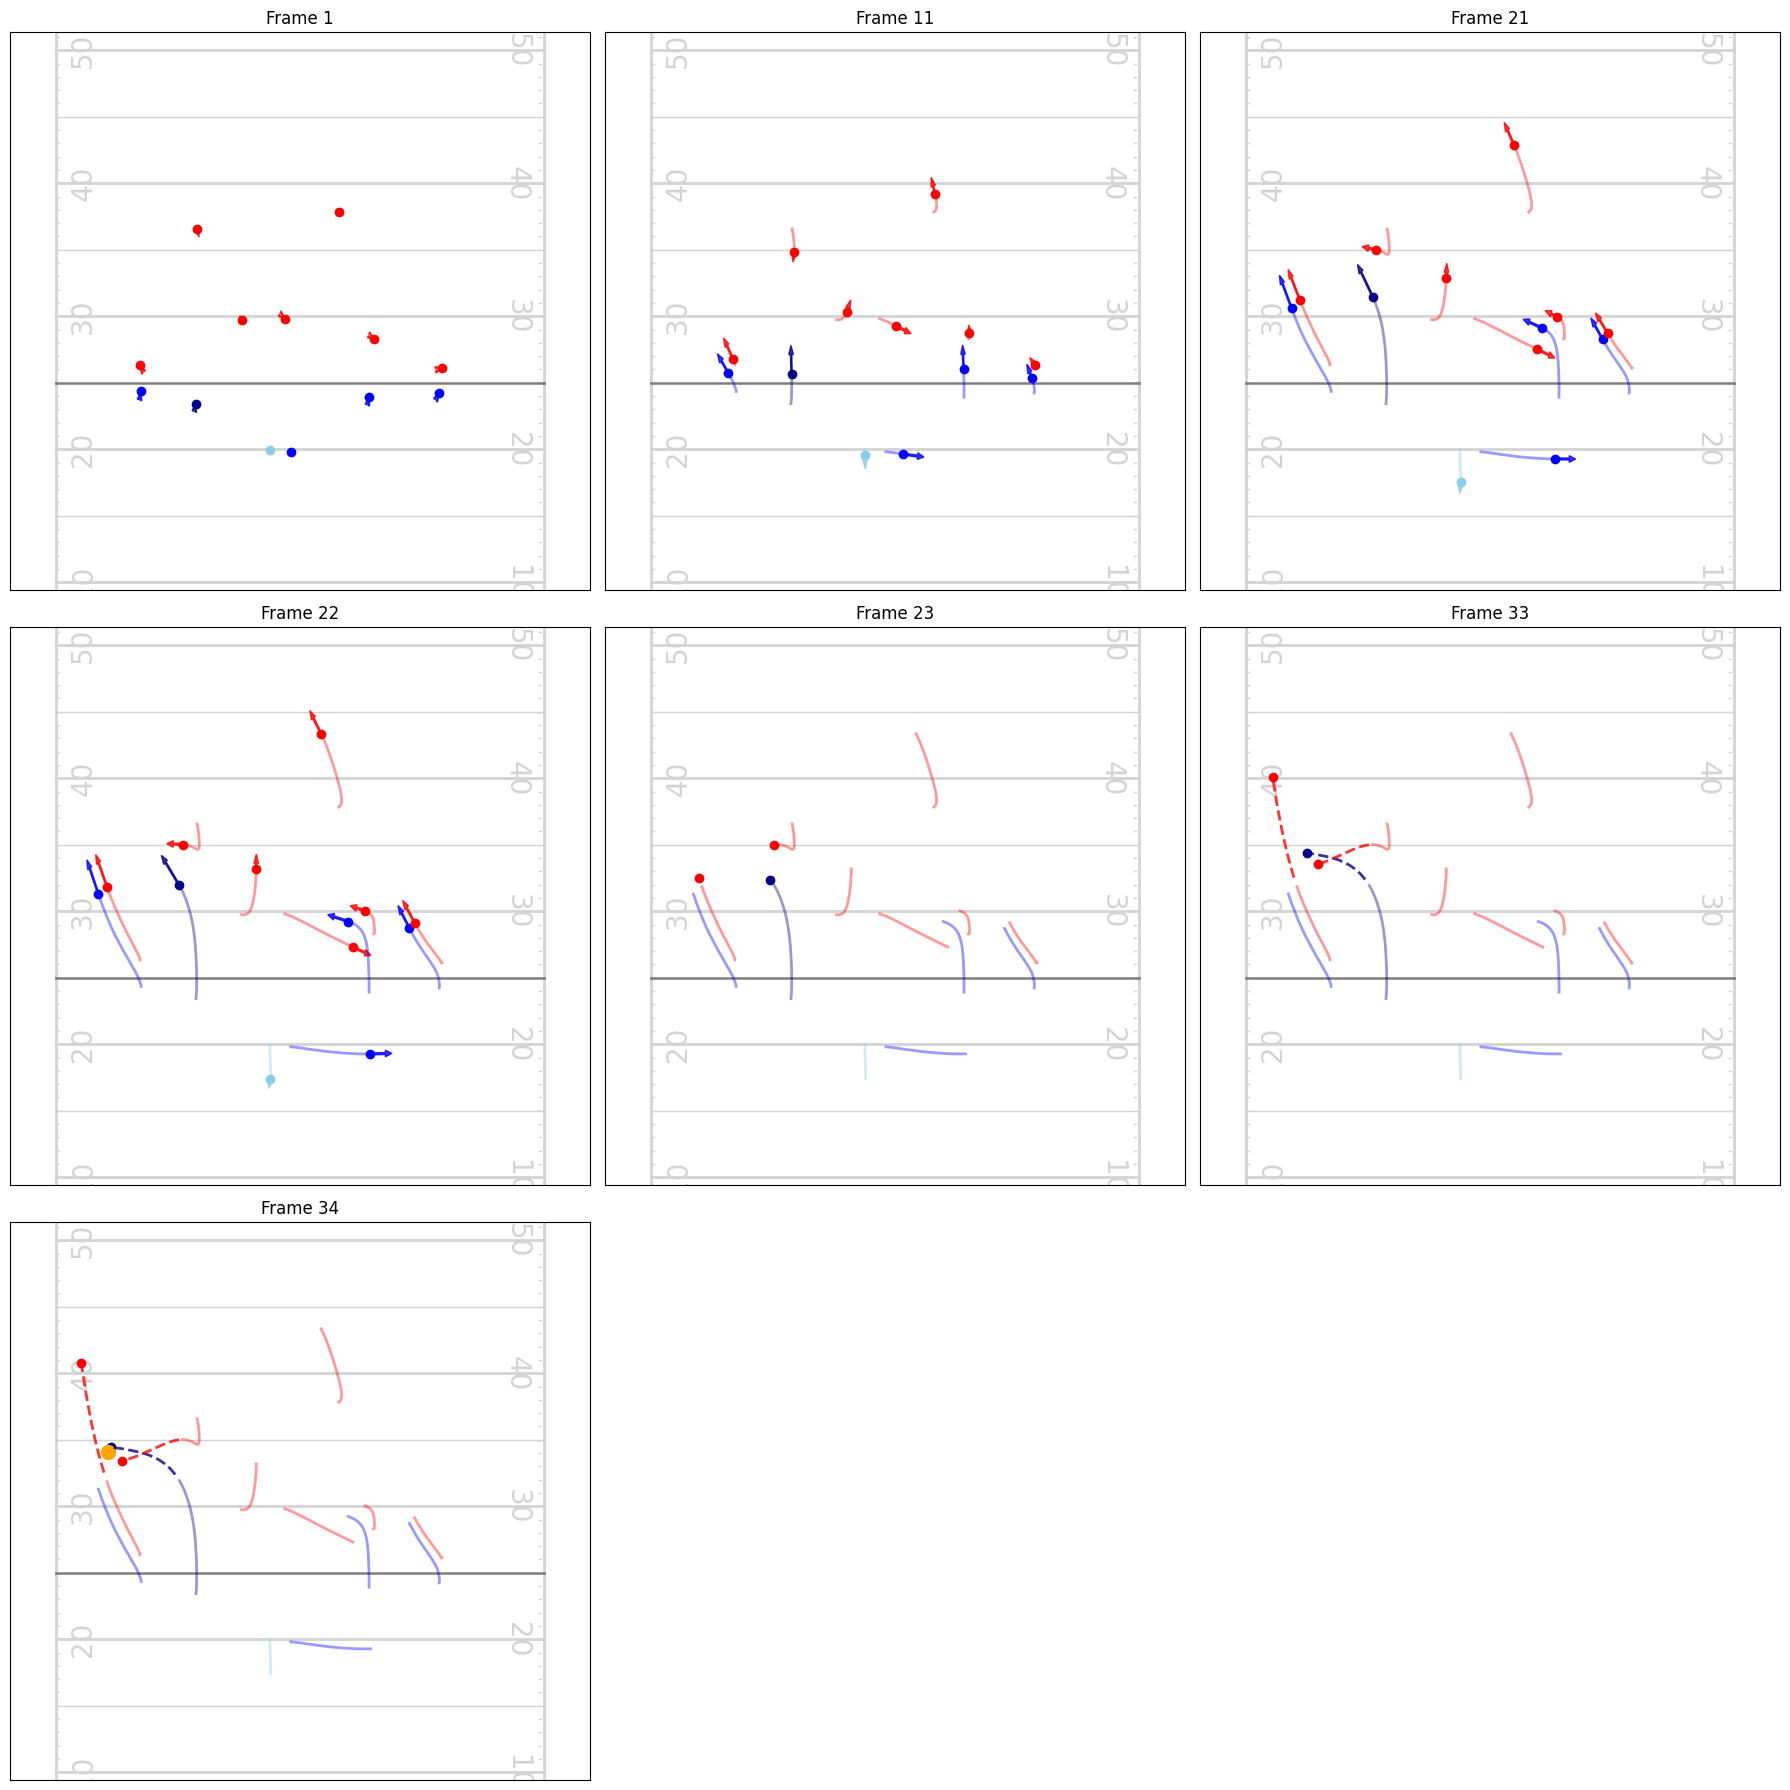

In [18]:
visualize_play(data, EXAMPLE_GAME, EXAMPLE_PLAY, arrows="motion", frame_step=10)

Same view with the arrows pointing along the body orientation `o` instead of the movement direction (fixed length): where a player looks compared to where he runs.

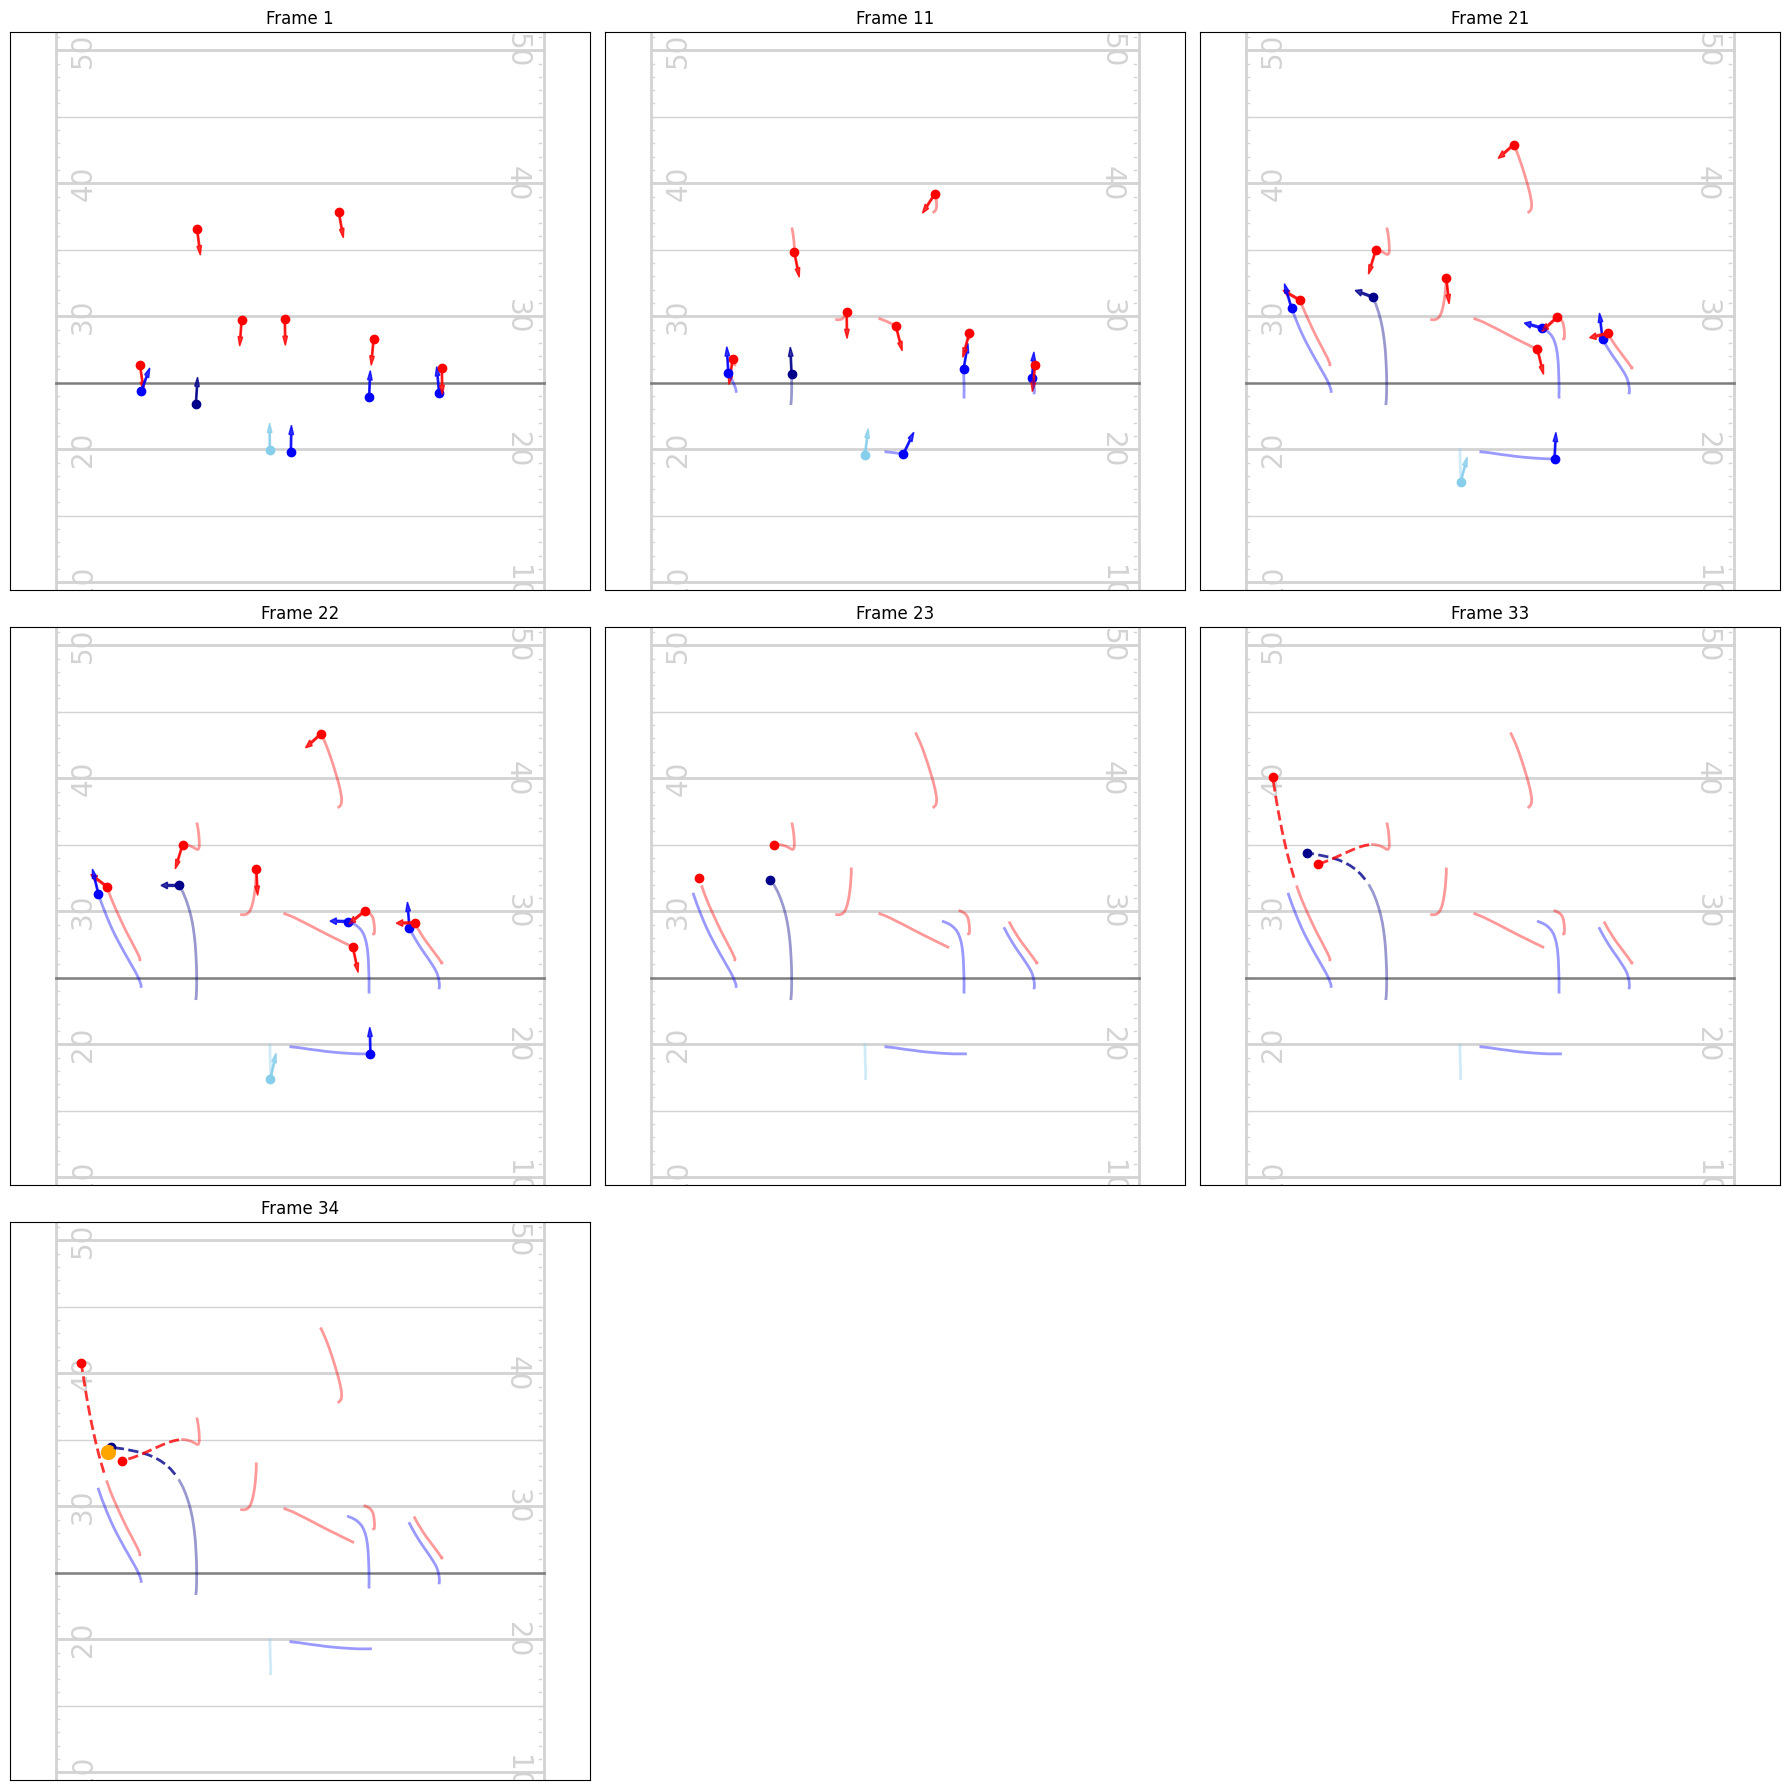

In [19]:
visualize_play(data, EXAMPLE_GAME, EXAMPLE_PLAY, arrows="orientation", frame_step=10)

---
# 5. Play Features

Statistics computed from the tracking data of a play: where the ball goes and how the targeted receiver and the defenders move relative to it.

## 5.1 Ball Travel Features

From the pre-pass frames of a play: time before the throw, air time, where the ball is thrown from and where it lands, and the distances and direction of its travel (to the sidelines, goal line and end zone too). These are the ball features fed to the model as global features (Chapter 6).

`include_outcome=False` excludes everything derived from the ball **landing point**, i.e. the **outcome** of the throw that the model has to predict. It is used by `get_global_features` when `global_mode="no_outcome"`.

In [20]:
def get_ball_stats(prepass_play_df, include_outcome=True):

    passer = prepass_play_df[prepass_play_df["player_role"] == "Passer"]["nfl_id"].unique()[0]

    scrimmage = prepass_play_df["absolute_yardline_number"].iloc[0]
    thrown_at_x = prepass_play_df[(prepass_play_df["frame_id"] == prepass_play_df["frame_id"].max()) & (prepass_play_df["nfl_id"] == passer)]["x"].values[0]
    thrown_at_y = prepass_play_df[(prepass_play_df["frame_id"] == prepass_play_df["frame_id"].max()) & (prepass_play_df["nfl_id"] == passer)]["y"].values[0]

    ball_stats = []
    entry = {
        "game_id": prepass_play_df["game_id"].iloc[0],
        "play_id": prepass_play_df["play_id"].iloc[0],
        "ball_throwing_time": prepass_play_df["frame_id"].max() / cfg.FRAME_RATE,
    }

    if include_outcome:
        entry["ball_air_time"] = prepass_play_df["num_frames_output"].values[0] / cfg.FRAME_RATE

    entry["scrimmage"] = scrimmage
    entry["ball_at_throw_x"] = thrown_at_x
    entry["ball_at_throw_y"] = thrown_at_y

    if include_outcome:
        landed_at_x = prepass_play_df["ball_land_x"].iloc[0]
        landed_at_y = prepass_play_df["ball_land_y"].iloc[0]

        dx, dy = landed_at_x - thrown_at_x, landed_at_y - thrown_at_y
        dist = np.sqrt(dx**2 + dy**2)
        dir = ((90 - np.degrees(np.arctan2(dy, dx)) + 180) % 360) - 180

        if landed_at_y < 0:
            side_dist = landed_at_y
        elif landed_at_y > 53.3:
            side_dist = 53.3 - landed_at_y
        else:
            side_dist = min(landed_at_y, 53.3 - landed_at_y)

        end_dist = 120 - landed_at_x
        entry["ball_at_landing_x"] = landed_at_x
        entry["ball_at_landing_y"] = landed_at_y
        entry["ball_travel_distance"] = dist
        entry["ball_travel_x"] = dx
        entry["ball_travel_y"] = dy
        entry["ball_travel_dir"] = dir
        entry["ball_sideline_distance"] = side_dist
        entry["ball_goalline_distance"] = end_dist - 10
        entry["ball_endzone_distance"] = end_dist

    ball_stats.append(entry)

    return ball_stats

Ball features of the example play, with all the outputs (`include_outcome=True`): one row, one column per feature.

In [21]:
prepass_df, postpass_df = get_play(data, EXAMPLE_GAME, EXAMPLE_PLAY)
pd.DataFrame(get_ball_stats(prepass_df))

,game_id,play_id,ball_throwing_time,ball_air_time,scrimmage,ball_at_throw_x,ball_at_throw_y,ball_at_landing_x,ball_at_landing_y,ball_travel_distance,ball_travel_x,ball_travel_y,ball_travel_dir,ball_sideline_distance,ball_goalline_distance,ball_endzone_distance
0,2023101900,78,2.2,1.2,35,27.42,29.87,44.080002,47.619999,24.343749,16.660002,17.749999,43.185662,5.680001,65.919998,75.919998


## 5.2 Targeted Receiver and Predicted Defenders

For the targeted receiver and each predicted defender: the expected path (position at the throw to the ball landing point), the real path (position at the throw to the position at landing) and the catch distance (gap between the player and the ball at landing). For a defender we also compute the distance to the receiver at the throw and at landing, a measure of the coverage. Each quantity comes as distance, `dx`, `dy` and direction. These statistics describe how the play unfolds and support the analysis; they are not model inputs.

The output shows the three tables (ball, targeted receiver, predicted defenders) of the example play.

In [22]:
ball_stats_df, target_stats_df, defenders_stats_df = get_play_stats(data, EXAMPLE_GAME, EXAMPLE_PLAY, get_ball_stats)
display(ball_stats_df)
display(target_stats_df)
display(defenders_stats_df)

,,ball_throwing_time,ball_air_time,scrimmage,ball_at_throw_x,ball_at_throw_y,ball_at_landing_x,ball_at_landing_y,ball_travel_distance,ball_travel_x,ball_travel_y,ball_travel_dir,ball_sideline_distance,ball_goalline_distance,ball_endzone_distance
game_id,play_id,,,,,,,,,,,,,,
2023101900,78,2.2,1.2,35,27.42,29.87,44.080002,47.619999,24.343749,16.660002,17.749999,43.185662,5.680001,65.919998,75.919998


,,,player_at_throw_x,player_at_throw_y,player_at_landing_x,player_at_landing_y,expected_path_distance,expected_path_dist_x,expected_path_dist_y,expected_path_dir,real_path_distance,real_path_dist_x,real_path_dist_y,real_path_dir,catch_distance,catch_dist_x,catch_dist_y,catch_dir
game_id,play_id,nfl_id,,,,,,,,,,,,,,,,
2023101900,78,44835,41.94,39.82,44.45,47.3,8.088238,2.140002,7.799999,15.342114,7.889899,2.51,7.48,18.54977,0.489181,-0.369998,0.319999,-49.144578


player_at_throw_x  player_at_throw_y  \
game_id    play_id nfl_id                                         
2023101900 78      44851               45.02              39.46   
                   44823               41.85              47.72   

                           player_at_landing_x  player_at_landing_y  \
game_id    play_id nfl_id                                             
2023101900 78      44851                 43.42                46.10   
                   44823                 50.80                50.53   

                           expected_path_distance  expected_path_dist_x  \
game_id    play_id nfl_id                                                 
2023101900 78      44851                 8.213962             -0.939998   
                   44823                 2.232243              2.230002   

                           expected_path_dist_y  expected_path_dir  \
game_id    play_id nfl_id                                            
2023101900 78      44851               8.159999          -6.571272   
                   44823              -0.100001          92.567623   

                           real_path_distance  real_path_dist_x  \
game_id    play_id nfl_id                                         
2023101900 78      44851             6.830051             -1.60   
                   44823             9.380757              8.95   

                           real_path_dist_y  real_path_dir  catch_distance  \
game_id    play_id nfl_id                                                    
2023101900 78      44851               6.64     -13.547939        1.657106   
                   44823               2.81      72.569460        7.323010   

                           catch_dist_x  catch_dist_y   catch_dir  \
game_id    play_id nfl_id                                           
2023101900 78      44851       0.660002      1.519999   23.471066   
                   44823      -6.719998     -2.910001 -113.414348   

                           defender_target_at_throw_distance  \
game_id    play_id nfl_id                                      
2023101900 78      44851                            3.100968   
                   44823                            7.900513   

                           defender_target_at_throw_dist_x  \
game_id    play_id nfl_id                                    
2023101900 78      44851                             -3.08   
                   44823                              0.09   

                           defender_target_at_throw_dist_y  \
game_id    play_id nfl_id                                    
2023101900 78      44851                              0.36   
                   44823                             -7.90   

                           defender_target_at_throw_dir  \
game_id    play_id nfl_id                                 
2023101900 78      44851                     -83.333340   
                   44823                     179.347292   

                           defender_target_at_landing_distance  \
game_id    play_id nfl_id                                        
2023101900 78      44851                              1.581423   
                   44823                              7.124282   

                           defender_target_at_landing_dist_x  \
game_id    play_id nfl_id                                      
2023101900 78      44851                                1.03   
                   44823                               -6.35   

                           defender_target_at_landing_dist_y  \
game_id    play_id nfl_id                                      
2023101900 78      44851                                1.20   
                   44823                               -3.23   

                           defender_target_at_landing_dir  
game_id    play_id nfl_id                                  
2023101900 78      44851                        40.640592  
                   44823                      -116.960684

## 5.3 Predicted Players Dataframe

The receiver and the defenders in one table (one row per predicted player, with the role as a column), aligned on the same columns. Plays without a targeted receiver or without tracked defenders are reported and handled.

In [23]:
get_predicted_players_df(data, EXAMPLE_GAME, EXAMPLE_PLAY, get_ball_stats)

player_role  player_at_throw_x  \
game_id    play_id nfl_id                                          
2023101900 78      44835    Targeted Receiver              41.94   
                   44851   Defensive Coverage              45.02   
                   44823   Defensive Coverage              41.85   

                           player_at_throw_y  player_at_landing_x  \
game_id    play_id nfl_id                                           
2023101900 78      44835               39.82                44.45   
                   44851               39.46                43.42   
                   44823               47.72                50.80   

                           player_at_landing_y  expected_path_distance  \
game_id    play_id nfl_id                                                
2023101900 78      44835                 47.30                8.088238   
                   44851                 46.10                8.213962   
                   44823                 50.53                2.232243   

                           expected_path_dist_x  expected_path_dist_y  \
game_id    play_id nfl_id                                               
2023101900 78      44835               2.140002              7.799999   
                   44851              -0.939998              8.159999   
                   44823               2.230002             -0.100001   

                           expected_path_dir  real_path_distance  \
game_id    play_id nfl_id                                          
2023101900 78      44835           15.342114            7.889899   
                   44851           -6.571272            6.830051   
                   44823           92.567623            9.380757   

                           real_path_dist_x  real_path_dist_y  real_path_dir  \
game_id    play_id nfl_id                                                      
2023101900 78      44835               2.51              7.48      18.549770   
                   44851              -1.60              6.64     -13.547939   
                   44823               8.95              2.81      72.569460   

                           catch_distance  catch_dist_x  catch_dist_y  \
game_id    play_id nfl_id                                               
2023101900 78      44835         0.489181     -0.369998      0.319999   
                   44851         1.657106      0.660002      1.519999   
                   44823         7.323010     -6.719998     -2.910001   

                            catch_dir  defender_target_at_throw_distance  \
game_id    play_id nfl_id                                                  
2023101900 78      44835   -49.144578                                NaN   
                   44851    23.471066                           3.100968   
                   44823  -113.414348                           7.900513   

                           defender_target_at_throw_dist_x  \
game_id    play_id nfl_id                                    
2023101900 78      44835                               NaN   
                   44851                             -3.08   
                   44823                              0.09   

                           defender_target_at_throw_dist_y  \
game_id    play_id nfl_id                                    
2023101900 78      44835                               NaN   
                   44851                              0.36   
                   44823                             -7.90   

                           defender_target_at_throw_dir  \
game_id    play_id nfl_id                                 
2023101900 78      44835                            NaN   
                   44851                     -83.333340   
                   44823                     179.347292   

                           defender_target_at_landing_distance  \
game_id    play_id nfl_id                                        
2023101900 78      44835                                   NaN   
     

---
# 6. Model Inputs

The three kinds of input of the network: node features (one vector per player and frame), edge features (relations between nodes) and global features (context of the play).

## 6.1 Node Features

For each player and frame: position, speed, acceleration, direction and orientation (6), one-hot role in the play (4), physical attributes with their global and within-position scores (12), one-hot side (2) and position (16): 40 features (`cfg.NODE_IN_DIM`). The roles are one-hot encoded with a fixed set of categories, so a play without one of the roles keeps the same 40 columns.

`preprocess_play` returns one array per frame (first column: `nfl_id`) and `pack_play_features` stacks the frames into a single array in frame-major order, node `t * P + n` being player `n` at frame `t`. The output shows the features of one frame, the ids of its players and the shape of the stacked array.

In [24]:
play_frames = preprocess_play(data, EXAMPLE_GAME, EXAMPLE_PLAY)
node_features, node_ids = get_node_features(play_frames, 1)
print("Frame 1: features", node_features.shape, "| players", node_ids)

all_node_features, all_node_ids, nfl_ids = pack_play_features(play_frames)
print("Whole play: features", all_node_features.shape, "| frames x players =",
      len(all_node_ids) // len(nfl_ids), "x", len(nfl_ids))

Frame 1: features (13, 36) | players [54514 38607 44851 44823 53505 53489 40017 46095 46116 44978 53454 53430
 44835]
Whole play: features (286, 36) | frames x players = 22 x 13


## 6.2 Edge Features

Two kinds of edges, kept apart because each has its own attention branch in the model. **Spatial**: in every frame each player is linked to his `K` nearest neighbours. **Temporal**: each player is linked to himself in the next frame. Every edge carries 7 attributes: distance, `dx`, `dy` and the differences of speed, acceleration, direction and orientation (angles wrapped to [-180, 180)).

The output gives the number of edges (spatial: frames x players x `K`; temporal: (frames - 1) x players) and the last two edges as `[destination, source]` node ids.

In [25]:
num_frames, num_players = len(all_node_ids) // len(nfl_ids), len(nfl_ids)
edge_features, edge_indexes, n_spatial = get_edge_features(all_node_features, num_frames, num_players,
                                                           k=cfg.K, return_splits=True)
print("Edge features:", edge_features.shape, "| spatial edges:", n_spatial,
      "| temporal edges:", edge_features.shape[0] - n_spatial)
print("Last two edges:", edge_indexes[-2:].tolist())

Edge features: (1703, 7) | spatial edges: 1430 | temporal edges: 273
Last two edges: [[271, 284], [272, 285]]


## 6.3 Global Features

Features of the whole play, not of a single player: they are projected and added to every node embedding in the model.

**Play context.** `preprocess_aux` builds them from the supplementary data: score of the offense and of the defense before the snap, yards to go, expected points (`expected_points`) and expected points added (`expected_points_added`), defenders in the box, and one-hot quarter, down, pass result, offense formation, route of the targeted receiver, play action and dropback type. The output shows the first rows: identifiers and features.

In [26]:
data.aux_df_preprocessed = preprocess_aux(data.aux_df)
data.aux_df_preprocessed.head()

,game_id,play_id,offense_score,defense_score,game_clock_norm,yards_to_go_norm,expected_points,expected_points_added,defenders_in_the_box,quarter_1,quarter_2,quarter_3,quarter_4,quarter_5,down_1,down_2,down_3,down_4,pass_result_C,pass_result_I,pass_result_IN,offense_formation_EMPTY,offense_formation_I_FORM,offense_formation_JUMBO,offense_formation_PISTOL,offense_formation_SHOTGUN,offense_formation_SINGLEBACK,offense_formation_WILDCAT,route_of_targeted_receiver_ANGLE,route_of_targeted_receiver_CORNER,route_of_targeted_receiver_CROSS,route_of_targeted_receiver_FLAT,route_of_targeted_receiver_GO,route_of_targeted_receiver_HITCH,route_of_targeted_receiver_IN,route_of_targeted_receiver_OUT,route_of_targeted_receiver_POST,route_of_targeted_receiver_SCREEN,route_of_targeted_receiver_SLANT,route_of_targeted_receiver_WHEEL,play_action_False,play_action_True,dropback_type_DESIGNED_ROLLOUT_LEFT,dropback_type_DESIGNED_ROLLOUT_RIGHT,dropback_type_SCRAMBLE,dropback_type_SCRAMBLE_ROLLOUT_LEFT,dropback_type_SCRAMBLE_ROLLOUT_RIGHT,dropback_type_TRADITIONAL
0,2023090700,3461,14,20,0.717778,0.12,-0.664416,2.945847,6,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True
1,2023090700,461,0,0,0.500000,0.10,1.926131,1.345633,7,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True
2,2023090700,1940,7,14,0.010000,0.10,0.281891,-0.081964,6,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True
3,2023090700,1711,7,7,0.050000,0.10,3.452352,2.342947,5,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
4,2023090700,1588,7,7,0.126667,0.10,1.921525,-0.324035,6,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True


**Outcome and `global_mode`.** Some global features describe how the throw ended: landing point and air time of the ball, `pass_result` and `expected_points_added`. Whether the model may use them is a modelling choice, so `get_global_features` builds the vector according to `global_mode`, one of the factors of the ablation study (Chapter 10):

* `"all"`: every global feature;
* `"none"`: no global feature at all (the model has no global branch).

The mode is applied **at the source**, when the vector is built, not by slicing the tensors afterwards: each mode produces exactly the input size the model expects.

**Normalization.** Ball features and scores are scaled to about [0, 1] with min-max bounds chosen a priori (`GLOBAL_FEATURE_MINMAX`: field size, maximum frames, and the ranges of expected points, `(-3, 7)`, and expected points added, `(-14, 10)`). The bounds are domain knowledge, not fitted on the data, so no statistic of validation or test data leaks into training; out-of-range values (e.g. throws out of bounds) are not clipped. The vector is therefore **not in raw units**: to draw scrimmage or landing point on a field, invert with `x * (max - min) + min` (`show_predictions` does it).

In [27]:
# Columns of aux_df_preprocessed that reveal the OUTCOME of the throw: removed by get_global_features
# when global_mode="no_outcome", in addition to what get_ball_stats(include_outcome=False) already leaves out.
AUX_OUTCOME_COLS_EXACT = {"expected_points_added"}
AUX_OUTCOME_COLS_PREFIX = ("pass_result_",)

# Min-max bounds (min, max) chosen a priori: x -> (x - min) / (max - min)
GLOBAL_FEATURE_MINMAX = {
    "ball_throwing_time":       (0.0, cfg.MAX_INPUT_FRAMES / cfg.FRAME_RATE),
    "ball_air_time":            (0.0, cfg.MAX_OUTPUT_FRAMES / cfg.FRAME_RATE),
    "expected_points":          (-3, 7),
    "expected_points_added":    (-14, 10),
    "scrimmage":                (10.0, 110.0),
    "ball_at_throw_x":          (0.0, 110.0),
    "ball_at_throw_y":          (0, 53.3),
    "ball_at_landing_x":        (-10.0, 125.0),
    "ball_at_landing_y":        (-5.0, 58.3),
    "ball_travel_distance":     (0.0, 70.0),
    "ball_travel_x":            (-10.0, 70.0),
    "ball_travel_y":            (-43.3, 43.3),      # hypothetically (-53.3, 53.3)
    "ball_travel_dir":          (-180.0, 180.0),
    "ball_sideline_distance":   (-5.0, 31.65),      # half the field width
    "ball_goalline_distance":   (-15.0, 105.0),
    "ball_endzone_distance":    (-5.0, 115.0),
    "offense_score":            (0.0, 70.0),
    "defense_score":            (0.0, 70.0),
    "defenders_in_the_box":     (0.0, 11.0),
}


def get_global_features(game_id, play_id, global_mode="all"):
    """Global feature vector of a play, according to global_mode ("all" / "no_outcome" / "none").
    Returns (pred_mask, vector): the mask of the players to predict in the first frame and the normalized vector."""
    play_df, _ = get_play(data, game_id, play_id)
    pred_mask = play_df[play_df["frame_id"] == 1]["player_to_predict"].to_numpy()

    if global_mode == "none":
        return pred_mask, np.zeros(0, dtype=np.float32)

    if global_mode not in ("all", "no_outcome"):
        raise ValueError(f"Unknown global_mode: {global_mode!r} (use 'none' / 'no_outcome' / 'all')")

    include_outcome = global_mode == "all"
    ball_df = pd.DataFrame(get_ball_stats(play_df, include_outcome=include_outcome))
    more_df = data.aux_df_preprocessed[(data.aux_df_preprocessed["game_id"] == game_id)
                                       & (data.aux_df_preprocessed["play_id"] == play_id)]

    if not include_outcome:
        outcome_cols = [
            c for c in more_df.columns
            if c in AUX_OUTCOME_COLS_EXACT or c.startswith(AUX_OUTCOME_COLS_PREFIX)
        ]
        more_df = more_df.drop(columns=outcome_cols)

    play_row = pd.merge(ball_df, more_df, on=["game_id", "play_id"], how="inner")

    # One row per play: make sure there are no duplicates
    play_row = play_row.groupby(["game_id", "play_id"]).first().reset_index()

    # game_id/play_id are identifiers (~2e9): as numeric features they would crush the rest of the vector.
    play_row = play_row.drop(columns=["game_id", "play_id"])

    # Min-max with the a priori bounds: only the columns listed in GLOBAL_FEATURE_MINMAX are touched
    # (the columns already normalized in preprocess_aux and the one-hot columns stay unchanged).
    for col, (lo, hi) in GLOBAL_FEATURE_MINMAX.items():
        if col in play_row.columns:
            play_row[col] = (play_row[col] - lo) / (hi - lo)

    return pred_mask, play_row.to_numpy(dtype=np.float32).ravel()

Size of the global vector of the example play for each mode: `none` gives an empty vector, `no_outcome` a shorter one than `all`. The values are the ones the model sees (normalized).

In [28]:
for mode in ["none", "all"]:
    pred_mask, global_vector = get_global_features(EXAMPLE_GAME, EXAMPLE_PLAY, mode)
    print(f"{mode:>10}: {len(global_vector):>3} features | players to predict: {int(pred_mask.sum())}")
print("\nFirst values (mode 'all'):", np.round(get_global_features(EXAMPLE_GAME, EXAMPLE_PLAY, "all")[1][:8], 3))

      none:   0 features | players to predict: 3
       all:  60 features | players to predict: 3

First values (mode 'all'): [0.179 0.128 0.25  0.249 0.56  0.401 0.831 0.348]


---
# 7. Data Pipeline

From the filtered plays to the batches the network is trained on: stratified split by play length, padded tensors and PyG graphs.

## 7.1 Stratified Sampling by Play Length

The pool of plays is reduced to `N_TOTAL` keeping the natural spread of the sequence lengths, instead of collapsing towards the most common ones. The plays are stratified on the **joint** length of the pre-pass frames (input) and of the frames to predict (output), and sampled as evenly as possible across the resulting bins (uniform across bins, not proportional to how common a length is), so rare short and long plays keep a fair share. The same bin labels then stratify the train/validation/test split, so the three sets have comparable length distributions, and the split is done by play, so no play is shared.

Bins are built by **frequency** (rank), not by value range: frame counts are integers with many ties, and a plain `pd.qcut` on the raw values would produce very unequal bins.

The output prints the bin sizes and shows three bar charts: the sizes of the input bins, of the output bins (nearly equal by construction) and of the joint bins, sorted by size. The joint bins are uneven because input and output lengths are correlated; the dashed line marks the target share per bin, and that imbalance is what the sampler corrects.

Input length bin sizes (rows per bin):
input_len_bin
(0.999, 941.2]        941
(941.2, 1881.4]       940
(1881.4, 2821.6]      940
(2821.6, 3761.8]      940
(3761.8, 4702.0]      940
(4702.0, 5642.2]      941
(5642.2, 6582.4]      940
(6582.4, 7522.6]      940
(7522.6, 8462.8]      940
(8462.8, 9403.0]      940
(9403.0, 10343.2]     941
(10343.2, 11283.4]    940
(11283.4, 12223.6]    940
(12223.6, 13163.8]    940
(13163.8, 14104.0]    941
Name: count, dtype: int64

Output length bin sizes (rows per bin):
output_len_bin
(0.999, 941.2]        941
(941.2, 1881.4]       940
(1881.4, 2821.6]      940
(2821.6, 3761.8]      940
(3761.8, 4702.0]      940
(4702.0, 5642.2]      941
(5642.2, 6582.4]      940
(6582.4, 7522.6]      940
(7522.6, 8462.8]      940
(8462.8, 9403.0]      940
(9403.0, 10343.2]     941
(10343.2, 11283.4]    940
(11283.4, 12223.6]    940
(12223.6, 13163.8]    940
(13163.8, 14104.0]    941
Name: count, dtype: int64

Joint length_bin cells: 225 (size range: 5-120, 10 below t

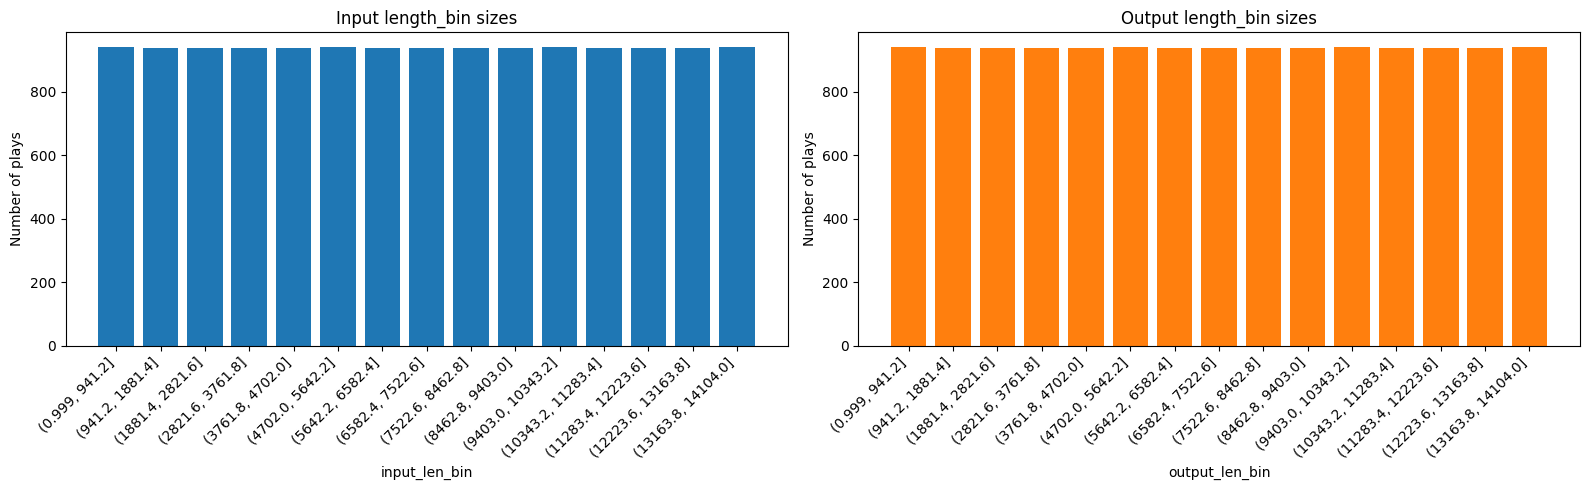

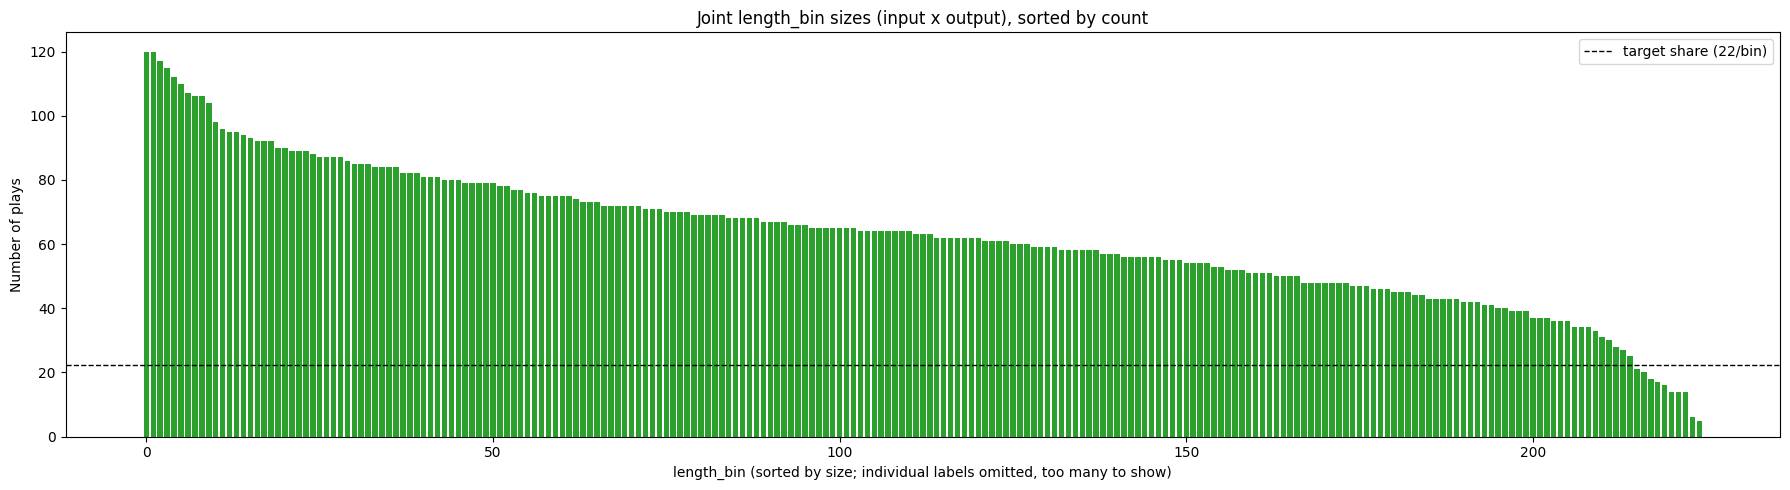

In [29]:
play_lengths = compute_play_lengths(data, cfg)
report_length_bins(play_lengths, cfg)

Sampling and split: `make_splits` draws the `N_TOTAL` plays and divides them into train, validation and test. The output gives the number of plays and how many length bins the pool covers.

In [30]:
splits = make_splits(play_lengths, cfg)

Sampled pool: 5000 plays (covering 225/225 length bins)
train=3000  val=1000  test=1000


## 7.2 Split Sanity Checks

The cell checks (with `assert`) that no `(game_id, play_id)` appears in two splits, then prints mean and standard deviation of the frame lengths of each split and plots their distributions. The three sets should overlap closely, otherwise the comparison between validation and test would be affected by different play lengths.

No (game_id, play_id) repeated across splits (train=3000, val=1000, test=1000)

Mean / std of frame lengths per split:
      num_input_frames           num_output_frames          
                  mean       std              mean       std
split                                                       
test         28.236000  9.106549         11.230000  4.992196
train        28.388333  9.345800         11.199667  4.864602
val          28.297000  9.227890         11.182000  4.839659


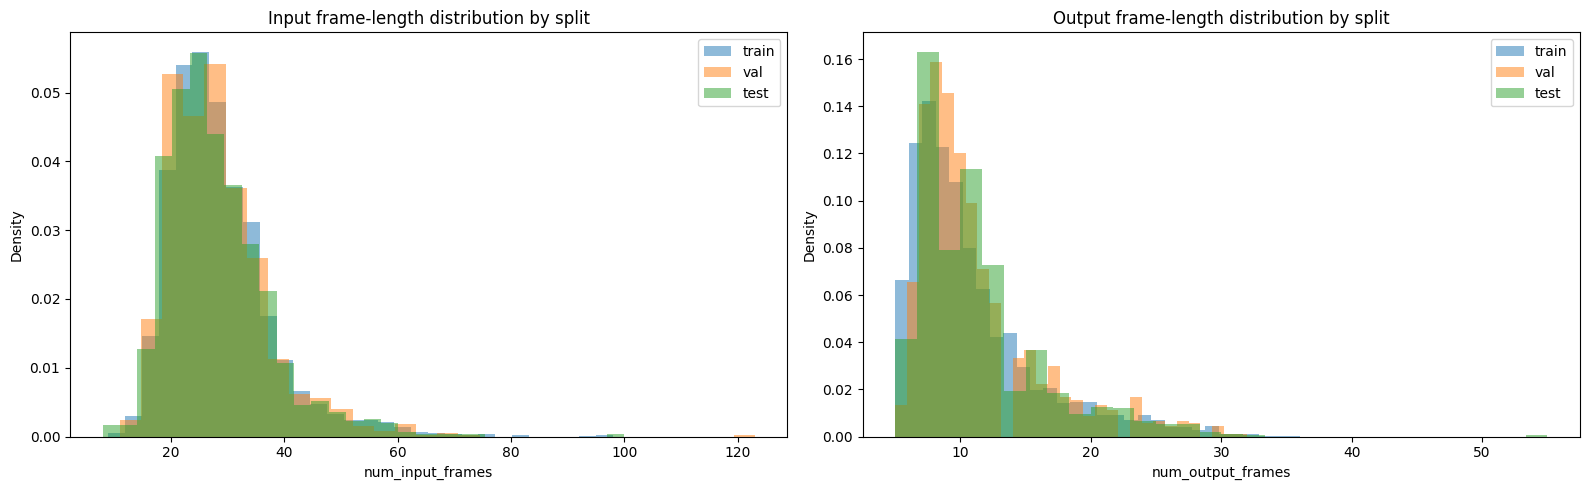

In [31]:
check_splits(splits)

## 7.3 Padded Tensors and PyG Batches

Each play becomes a padded tensor set (up to `MAX_INPUT_FRAMES` frames and `MAX_INPUT_NODES` players, with masks marking what is real) and then a PyG graph: the padding is cut away, spatial and temporal edges are stored apart, and the target trajectory and its mask travel with the graph, so a list of batches is all the training needs.

`BatchProvider` builds the graphs once per `global_mode` (the slow step) and collates them into batches for the requested batch size. Only the last combination is kept in memory, which is enough for the ablations of Chapter 10 and avoids running out of RAM. The output shows a sample batch: `x` stacks the nodes of the plays of the batch, `y_target`/`y_mask` have shape `[batch, output frames, players, 2]` / `[batch, output frames, players]`.

In [36]:
batches = BatchProvider(data, splits, cfg,
                        preprocess_play_fn=lambda game, play: preprocess_play(data, game, play),
                        global_features_fn=get_global_features)

train_batches, val_batches, test_batches, global_in_dim = batches.get(cfg.BATCH_SIZE, "all")
print(f"batches: train {len(train_batches)} | val {len(val_batches)} | test {len(test_batches)} "
      f"| global features: {global_in_dim}")

sample = train_batches[0]
print("\nSample batch:", sample)
print("y_target:", tuple(sample.y_target.shape), "| y_mask:", tuple(sample.y_mask.shape))

Processing Train:   0%|          | 0/3000 [00:00<?, ?it/s]

Graphs Train (all):   0%|          | 0/3000 [00:00<?, ?it/s]

Processing Validation:   0%|          | 0/1000 [00:00<?, ?it/s]

Graphs Validation (all):   0%|          | 0/1000 [00:00<?, ?it/s]

Processing Test:   0%|          | 0/1000 [00:00<?, ?it/s]

Graphs Test (all):   0%|          | 0/1000 [00:00<?, ?it/s]

batches: train 3000 | val 1000 | test 1000 | global features: 60

Sample batch: DataBatch(x=[360, 36], edge_index_spatial=[2, 1800], edge_attr_spatial=[1800, 7], edge_index_temporal=[2, 348], edge_attr_temporal=[348, 7], x_global=[1, 60], num_frames=[1], num_output_frames=[1], predicted_nodes=[1], last_nodes=[1], y_target=[1, 94, 17, 2], y_mask=[1, 94, 17], batch=[360], ptr=[2])
y_target: (1, 94, 17, 2) | y_mask: (1, 94, 17)


---
# 8. Model

A temporal graph attention network (TGAT) encodes each play; a global branch adds the context of the play; a per-player regressor decodes the whole trajectory in one shot.

## 8.1 Graph Attention Layer

Graph attention layer (Veličković et al., 2018), extended so that the **edge attributes** take part in the attention score: for a node `i` and its neighbour `j`, the score is `LeakyReLU(a · [h_i ‖ h_j ‖ e_ij])`, normalized with a softmax over the neighbours of `i`; the message is `alpha_ij · (h_j + e_ij)`. The aggregation is a sum (`aggr='add'`): the coefficients already sum to 1 over the neighbours, so the sum is a weighted mean and a `mean` aggregation would normalize twice.

In [32]:
class GATEncoder(MessagePassing):
    """Graph attention layer whose attention score also uses the edge attributes."""

    def __init__(self, node_in_dim, edge_in_dim, hidden_dim, negative_slope=0.2):
        super().__init__(aggr='add', node_dim=0)
        self.node_proj = nn.Linear(node_in_dim, hidden_dim)
        self.edge_proj = nn.Linear(edge_in_dim, hidden_dim)

        # Attention vector 'a': a scalar score from the concatenation (node_i, node_j, edge_ij)
        self.attn = nn.Linear(3 * hidden_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(negative_slope)

    def forward(self, x, edge_index, edge_attr):
        node_h = self.node_proj(x)
        edge_h = self.edge_proj(edge_attr)
        return self.propagate(edge_index, x=node_h, edge_attr=edge_h)

    def message(self, x_i, x_j, edge_attr, index, ptr, size_i):
        # x_i: features of the target node (who receives the message); x_j: of the neighbour (who sends it)
        e_ij = self.leaky_relu(self.attn(torch.cat([x_i, x_j, edge_attr], dim=-1))).squeeze(-1)

        # Softmax of the scores over the neighbours of each target node ('index' = destination of each edge)
        alpha = softmax(e_ij, index, ptr, size_i)

        return alpha.unsqueeze(-1) * (x_j + edge_attr)

    def update(self, aggr_out):
        return aggr_out

## 8.2 Spatio-Temporal Encoder

Two attention branches with the same layer: the **spatial** one runs on the edges between players of the same frame, the **temporal** one on the edges of the same player across frames. The hidden size is split one third to the spatial branch and two thirds to the temporal one, and a linear layer fuses the two embeddings.

Each branch can stack more than one such layer (`cfg.GAT_NUM_LAYERS`, ELU between layers, none after the last one): with 2 layers a player's embedding also picks up its neighbours' neighbours (two hops away, not just its direct `K` spatial neighbours, or two steps back in time for the temporal branch), at the cost of a larger model. The default of 1 layer is the original single-hop encoder.


In [33]:
class TGATEncoder(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim, out_dim, num_layers=1):
        super().__init__()

        hidden_dim_spatial = hidden_dim // 3
        hidden_dim_temporal = hidden_dim - hidden_dim_spatial

        # First layer projects from node_in_dim; every following layer projects from the PREVIOUS layer's output
        # (hidden_dim_spatial/temporal), since that is what it now receives as node features. Edge features are
        # re-projected from edge_in_dim at every layer: a play's edges do not change between layers, only the node
        # embeddings the attention score is computed from.
        self.spatial_gats = nn.ModuleList([
            GATEncoder(node_in_dim if i == 0 else hidden_dim_spatial, edge_in_dim, hidden_dim_spatial)
            for i in range(num_layers)
        ])
        self.temporal_gats = nn.ModuleList([
            GATEncoder(node_in_dim if i == 0 else hidden_dim_temporal, edge_in_dim, hidden_dim_temporal)
            for i in range(num_layers)
        ])
        self.fuse = nn.Linear(hidden_dim_spatial + hidden_dim_temporal, out_dim)

    def _stack(self, layers, x, edge_index, edge_attr):
        h = x
        for i, layer in enumerate(layers):
            h = layer(h, edge_index, edge_attr)
            if i < len(layers) - 1:
                h = F.elu(h)      # only BETWEEN layers: the last one feeds `fuse` directly, like before
        return h

    def forward(self, x, edge_index_spatial, edge_attr_spatial,
                      edge_index_temporal, edge_attr_temporal):

        h_spatial = self._stack(self.spatial_gats, x, edge_index_spatial, edge_attr_spatial)
        h_temporal = self._stack(self.temporal_gats, x, edge_index_temporal, edge_attr_temporal)

        return self.fuse(torch.cat([h_spatial, h_temporal], dim=-1))

## 8.3 Full Model

`PyGNetTGAT` encodes the graph of the play and adds the projected global features to every node embedding (this branch does not exist when `global_in_dim=0`, i.e. `global_mode="none"`). For each player of the last observed frame it takes the embedding plus the last position `(x, y)`, pads the players to `MAX_OUTPUT_NODES` and feeds them to an MLP that outputs all the `MAX_OUTPUT_FRAMES` future positions **in one shot**, without autoregression. The frames beyond those of the play are set to zero. The size of the encoder is `hidden_dim - 2`, so that the embedding plus the two coordinates has size `hidden_dim`. The regressor's hidden width and the depth of each GAT branch (8.2) are both configurable, not architectural constants: `make_model(global_in_dim, hidden_dim, gat_num_layers, regressor_hidden_dim)` takes them as explicit arguments (falling back to `cfg.GAT_NUM_LAYERS` / `cfg.REGRESSOR_HIDDEN_DIM` when omitted), so `ExperimentRunner` can vary them from one run to the next exactly like `hidden_dim` -- see Chapter 10.4-10.5.

In [34]:
class PyGNetTGAT(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, global_in_dim, hidden_dim=128, out_dim=32,
                 max_frames=cfg.MAX_OUTPUT_FRAMES, max_players=cfg.MAX_OUTPUT_NODES,
                 num_gat_layers=1, regressor_hidden_dim=512):
        super().__init__()

        self.encoder = TGATEncoder(node_in_dim, edge_in_dim, hidden_dim - 2, out_dim, num_layers=num_gat_layers)

        # Must match the output of the encoder (hidden_dim - 2), not hidden_dim
        self.global_proj = nn.Linear(global_in_dim, hidden_dim - 2) if global_in_dim else None

        self.max_frames = max_frames
        self.max_players = max_players

        # Final regressor: per-player decoding, no interaction layer
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, regressor_hidden_dim),
            nn.ReLU(),
            nn.Linear(regressor_hidden_dim, self.max_frames * 2)
        )

    def forward(self, batch: Batch):
        # 1. Encoding (the TGAT does the spatio-temporal work)
        node_embed = self.encoder(
            batch.x,
            batch.edge_index_spatial, batch.edge_attr_spatial,
            batch.edge_index_temporal, batch.edge_attr_temporal
        )
        if self.global_proj and hasattr(batch, 'x_global'):
            global_embed = self.global_proj(batch.x_global)          # [B, H]
            node_embed = node_embed + global_embed[batch.batch]      # broadcast to nodes

        # 2. Padding: last observed frame of each play, padded to the max number of players
        B = batch.num_graphs

        padded_nodes = torch.zeros((B, self.max_players, node_embed.shape[1] + 2), device= node_embed.device)

        for i in range(B):
            # last_nodes[i] is local to graph i (the last num_players rows of its range), but node_embed/batch.x
            # are concatenated globally by Batch.from_data_list. batch.ptr[i] is the global start offset of
            # graph i (already computed by PyG): adding it gives the global indices in O(num_players).
            offset = int(batch.ptr[i])
            last_idx = torch.as_tensor(batch.last_nodes[i], dtype=torch.long, device=node_embed.device) + offset

            h_last = node_embed[last_idx]
            last_xy = batch.x[last_idx, :2]

            h_final = torch.cat([h_last, last_xy], dim=-1)

            padded_node = torch.zeros((self.max_players, h_final.shape[1]), device=node_embed.device)
            padded_node[:len(h_final)] = h_final

            padded_nodes[i] = padded_node

        # 3. One-shot per-player decoding (no interaction/attention layer)
        out = self.regressor(padded_nodes)

        reshaped_out = out.view(B, self.max_players, self.max_frames, 2).permute(0, 2, 1, 3)
        # The time axis here are the OUTPUT frames: zeroing beyond num_frames (INPUT frames) would truncate the
        # valid tails of the plays whose post-pass is longer than the pre-pass.
        for i in range(B):
            reshaped_out[i, batch.num_output_frames[i]:] = 0

        return reshaped_out


def make_model(global_in_dim, hidden_dim, gat_num_layers=None, regressor_hidden_dim=None):
    """Model factory used by the experiments: hidden size and global input size always change between runs; GAT
    depth and regressor width now do too -- ExperimentRunner passes them explicitly on every call (falling back to
    cfg.GAT_NUM_LAYERS / cfg.REGRESSOR_HIDDEN_DIM only when not given, e.g. when make_model is called directly, as
    in the parameter-count cells of Chapter 10). Because every combination of the five factors gets its own
    run_label (ExperimentRunner.make_label), different architectures never collide on the same checkpoint file.
    """
    gat_num_layers = gat_num_layers if gat_num_layers is not None else cfg.GAT_NUM_LAYERS
    regressor_hidden_dim = regressor_hidden_dim if regressor_hidden_dim is not None else cfg.REGRESSOR_HIDDEN_DIM
    return PyGNetTGAT(cfg.NODE_IN_DIM, cfg.EDGE_IN_DIM, global_in_dim, hidden_dim, hidden_dim - 2,
                      num_gat_layers=gat_num_layers, regressor_hidden_dim=regressor_hidden_dim)

## 8.4 Model Size and Dimension Flow

Two views of the same model, both computed from `cfg`/`make_model`, never typed in by hand. The diagram below shows the dimension pipeline end to end; the encoder is deliberately sized to `hidden_dim - 2` so that concatenating the player's own last observed `(x, y)` position afterwards lands back exactly on `hidden_dim`, never losing that position to a bottleneck. The table underneath is `torch_geometric.nn.summary()` run on one real batch (`train_batches[0]`) through a freshly-built, untrained model -- the standard PyG layer-by-layer breakdown (input/output shape and parameter count per layer), not a hand-rolled one. The global-features branch (right panel of the arrow) only exists when `global_in_dim > 0`, i.e. `global_mode` is `"all"`.



In [37]:
def plot_architecture(cfg, global_in_dim, gat_num_layers=None, regressor_hidden_dim=None):
    """Schematic of PyGNetTGAT's dimension flow, left to right. Every dimension is read off `cfg`, never
    hand-typed, so it can't silently go stale if the config changes."""
    import matplotlib.patches as mpatches

    gat_num_layers = gat_num_layers or cfg.GAT_NUM_LAYERS
    regressor_hidden_dim = regressor_hidden_dim or cfg.REGRESSOR_HIDDEN_DIM
    hd = cfg.HIDDEN_DIM
    enc_dim = hd - 2
    spatial_dim = enc_dim // 3
    temporal_dim = enc_dim - spatial_dim
    out_flat = cfg.MAX_OUTPUT_FRAMES * 2

    stages = [
        ("Node + edge\nfeatures", f"x: [N, {cfg.NODE_IN_DIM}]\nedge_attr: [E, {cfg.EDGE_IN_DIM}]"),
        (f"Spatio-temporal\nGAT ×{gat_num_layers}", f"spatial {spatial_dim} + temporal {temporal_dim}\n→ {enc_dim}"),
        ("Fuse", f"Linear({enc_dim}→{enc_dim})"),
        ("+ last (x, y)", f"{enc_dim} + 2 = {hd}"),
        ("Pad + regress", f"pad to {cfg.MAX_OUTPUT_NODES} players\nLinear({hd}→{regressor_hidden_dim}→{out_flat})"),
        ("Output", f"[{cfg.MAX_OUTPUT_FRAMES}, {cfg.MAX_OUTPUT_NODES}, 2]"),
    ]

    fig, ax = plt.subplots(figsize=(15, 4.4))

    n = len(stages)
    box_w, box_h, gap = 2.3, 1.7, 0.55
    total_w = n * box_w + (n - 1) * gap
    x0 = -total_w / 2

    box_centers = []
    for i, (title, detail) in enumerate(stages):
        x = x0 + i * (box_w + gap)
        box_centers.append(x + box_w / 2)
        box = mpatches.FancyBboxPatch((x, -box_h / 2), box_w, box_h,
                                      boxstyle="round,pad=0.05,rounding_size=0.08",
                                      linewidth=1.6, edgecolor="tab:blue", facecolor="white", zorder=2)
        ax.add_patch(box)
        ax.text(x + box_w / 2, box_h / 2 - 0.4, title, ha="center", va="center", fontsize=10.5, fontweight="bold")
        ax.text(x + box_w / 2, -0.15, detail, ha="center", va="center", fontsize=8.7, family="monospace")
        if i > 0:
            prev_right = x0 + (i - 1) * (box_w + gap) + box_w
            ax.annotate("", xy=(x, 0), xytext=(prev_right, 0),
                       arrowprops=dict(arrowstyle="-|>", color="black", lw=1.3))

    # Global-features branch: merges into "Fuse" (stage index 2) from below, only when it exists.
    if global_in_dim:
        gx = box_centers[2]
        gbox_w, gbox_h = 2.1, 1.0
        gy = -1.75
        gbox = mpatches.FancyBboxPatch((gx - gbox_w / 2, gy - gbox_h / 2), gbox_w, gbox_h,
                                       boxstyle="round,pad=0.05,rounding_size=0.08",
                                       linewidth=1.6, edgecolor="tab:orange", facecolor="white",
                                       linestyle="--", zorder=2)
        ax.add_patch(gbox)
        ax.text(gx, gy + 0.18, "Global features", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="tab:orange")
        ax.text(gx, gy - 0.22, f"[{global_in_dim}] → Linear → [{enc_dim}]\nbroadcast-added",
                ha="center", va="center", fontsize=8, family="monospace", color="tab:orange")
        ax.annotate("", xy=(gx, -box_h / 2), xytext=(gx, gy + gbox_h / 2),
                   arrowprops=dict(arrowstyle="-|>", color="tab:orange", lw=1.3, linestyle="--"))
        ax.set_ylim(-2.5, 1.3)
    else:
        ax.set_ylim(-1.3, 1.3)

    ax.set_xlim(x0 - 0.4, x0 + total_w + 0.4)
    ax.axis("off")
    ax.set_title(f"hidden_dim={hd}  |  gat_num_layers={gat_num_layers}  |  regressor_hidden_dim={regressor_hidden_dim}"
                f"  |  global_mode {'all' if global_in_dim else 'none'}", fontsize=11)
    plt.tight_layout()
    plt.show()

# Row-by-row layer breakdown (input/output shape and parameter count per layer, Keras-style) -- torch_geometric's
# own `summary()`, not a hand-rolled table, so it can't drift from what the layers actually do. It needs one real
# forward pass, so it runs on a real batch (train_batches[0], already built in 7.3) through a freshly-constructed,
# untrained model -- weights don't matter here, only shapes and parameter counts do.
from torch_geometric.nn import summary as pyg_summary

arch_model = make_model(global_in_dim, cfg.HIDDEN_DIM, cfg.GAT_NUM_LAYERS, cfg.REGRESSOR_HIDDEN_DIM)
print(pyg_summary(arch_model, train_batches[0], leaf_module=None))


+----------------------------------+-----------------------------------------------------+----------------+----------+
| Layer                            | Input Shape                                         | Output Shape   | #Param   |
|----------------------------------+-----------------------------------------------------+----------------+----------|
| PyGNetTGAT                       | [360, 360]                                          | [1, 94, 17, 2] | 75,620   |
| ├─(encoder)TGATEncoder           | [360, 36], [2, 1800], [1800, 7], [2, 348], [348, 7] | [360, 62]      | 6,882    |
| │    └─(spatial_gats)ModuleList  | --                                                  | --             | 960      |
| │    │    └─(0)GATEncoder        | [360, 36], [2, 1800], [1800, 7]                     | [360, 20]      | 960      |
| │    └─(temporal_gats)ModuleList | --                                                  | --             | 2,016    |
| │    │    └─(0)GATEncoder        | [360, 36], 

---
# 9. Training and Baseline

## 9.1 Loss and Metric

The **metric** is the masked RMSE in yards, computed only on the valid (player, frame) pairs: it is the number compared across runs. The **loss** that is optimized is composite and adds two terms to it: the error on the last valid frame of each player, the final displacement error (FDE, weight `W_FDE`), because for a play the error at the end of the trajectory matters more than in the intermediate frames, and a smoothness regularizer (weight `W_SMOOTH`) on the jerk, the second difference of the predicted trajectory, since the one-shot regressor has no architectural constraint of continuity between frames.

In [38]:
def masked_rmse(y_pred, y_true, output_mask):
    """y_pred, y_true: [B, T, N, 2]; output_mask: [B, T, N] (True for valid data)."""
    mask = output_mask.bool().unsqueeze(-1).expand_as(y_pred)  # [B, T, N, 2]

    pred_masked = y_pred[mask]
    true_masked = y_true[mask]

    mse = F.mse_loss(pred_masked, true_masked, reduction='mean')
    return torch.sqrt(mse)

In [39]:
def _last_frame_mask(output_mask):
    """One True per (b, n): the last frame for which output_mask is True. Used by the FDE term, which weighs only the
    error on the last predicted instant of each play/player. The trick t_idx * mask also works when the only valid
    frame is t=0 (the max stays 0, the right index, instead of a false 'no match')."""
    T = output_mask.shape[1]
    t_idx = torch.arange(T, device=output_mask.device).view(1, T, 1)
    last_idx = (t_idx * output_mask).amax(dim=1, keepdim=True)   # [B,1,N]
    return (t_idx == last_idx) & output_mask                     # [B,T,N]


def _smoothness_penalty(y_pred, output_mask):
    """Penalizes the second derivative (jerk) of the PREDICTED trajectory: it is not compared with the ground truth,
    it is a pure regularizer on the smoothness of the output. It compensates the tendency of the one-shot regressor
    to produce jumps, which used to be cleaned up in post-processing."""
    jerk = y_pred[:, 2:] - 2 * y_pred[:, 1:-1] + y_pred[:, :-2]                  # [B,T-2,N,2]
    jerk_mask = output_mask[:, :-2] & output_mask[:, 1:-1] & output_mask[:, 2:]  # needs a valid triplet
    m = jerk_mask.unsqueeze(-1).expand_as(jerk)
    if not m.any():
        return torch.tensor(0.0, device=y_pred.device)
    return torch.sqrt(F.mse_loss(jerk[m], torch.zeros_like(jerk[m]), reduction='mean'))


def masked_loss(y_pred, y_true, output_mask):
    """Composite loss: RMSE on all valid frames + W_FDE * RMSE on the last valid frame of each player
    + W_SMOOTH * smoothness penalty on the prediction."""
    mask = output_mask.bool().unsqueeze(-1).expand_as(y_pred)
    rmse = torch.sqrt(F.mse_loss(y_pred[mask], y_true[mask], reduction='mean'))

    fde_mask = _last_frame_mask(output_mask).unsqueeze(-1).expand_as(y_pred)
    fde = torch.sqrt(F.mse_loss(y_pred[fde_mask], y_true[fde_mask], reduction='mean'))

    smooth = _smoothness_penalty(y_pred, output_mask)

    return rmse + cfg.W_FDE * fde + cfg.W_SMOOTH * smooth

## 9.2 Training Procedure

The training loop lives in `nfl_bdb.training` and is the same for the baseline and for every ablation (`ExperimentRunner.run` calls `run_training`). Optimizer: AdamW with gradient clipping. The learning rate is multiplied by `SCHEDULER_FACTOR` (0.5) by `ReduceLROnPlateau` when the validation loss stops improving, and the training stops early when it keeps not improving; both use the same relative threshold (1%), so they react to the same idea of plateau. Any improvement, even a tiny one, saves the checkpoint; the test set is evaluated once, on the best checkpoint of the run. The seed is reset at the start of each run.

The runner saves the results of every finished run in `outputs/experiment_results.json`: if the session is interrupted, `load_results()` and `run()` resume the study without repeating the finished runs.

## 9.3 Starting Point

Chapter 10 runs a **sequential** (greedy, coordinate-wise) search, not a classic one-factor-at-a-time ablation against a single fixed baseline: each stage fixes the winner of the previous stage(s) before exploring the next factor, in this order -- global features, batch size, hidden dimension, GAT layers, regressor width. `BASELINE` below is the *starting* point of that search (batch size 8, `cfg.HIDDEN_DIM`, `cfg.GAT_NUM_LAYERS` GAT layer(s), regressor width `cfg.REGRESSOR_HIDDEN_DIM`, no global features) and is updated in place as the search proceeds. The cell below trains this starting configuration; it mostly serves as the reference point for the global-features comparison of 10.1.

In [40]:
runner = ExperimentRunner(cfg, batches, make_model, loss_fn=masked_loss, metric_fn=masked_rmse, device=device,
                          results_path= cfg.OUTPUT_DIR / "experiment_results.json")#"NFL-BDB-26" / cfg.OUTPUT_DIR / "experiment_results.json")
runner.load_results()      # resume: runs already finished are not repeated

BASELINE = dict(batch_size=8, hidden_dim=cfg.HIDDEN_DIM, global_mode="none",
                gat_num_layers=cfg.GAT_NUM_LAYERS, regressor_hidden_dim=cfg.REGRESSOR_HIDDEN_DIM)

Loaded 11 finished runs from outputs/experiment_results.json: ['bs8_hd64_gl1_rg256_none', 'bs8_hd64_gl1_rg256_all', 'bs1_hd64_gl1_rg256_all', 'bs64_hd64_gl1_rg256_all', 'bs1_hd8_gl1_rg256_all', 'bs1_hd256_gl1_rg256_all', 'bs1_hd64_gl1_rg64_all', 'bs1_hd64_gl1_rg512_all', 'bs1_hd64_gl2_rg256_all', 'bs1_hd64_gl3_rg256_all', 'bs1_hd64_gl1_rg256_all_10k']


In [41]:
baseline = runner.run(**BASELINE, verbose=True)

[bs8_hd64_gl1_rg256_none] already done (test RMSE 1.0320), skipped


Learning curves of the starting run: training and validation loss (left axis) and learning rate (right axis, log scale). The validation loss should decrease and flatten; the learning rate drops in steps every time the plateau logic fires. A growing gap between the two losses signals overfitting.

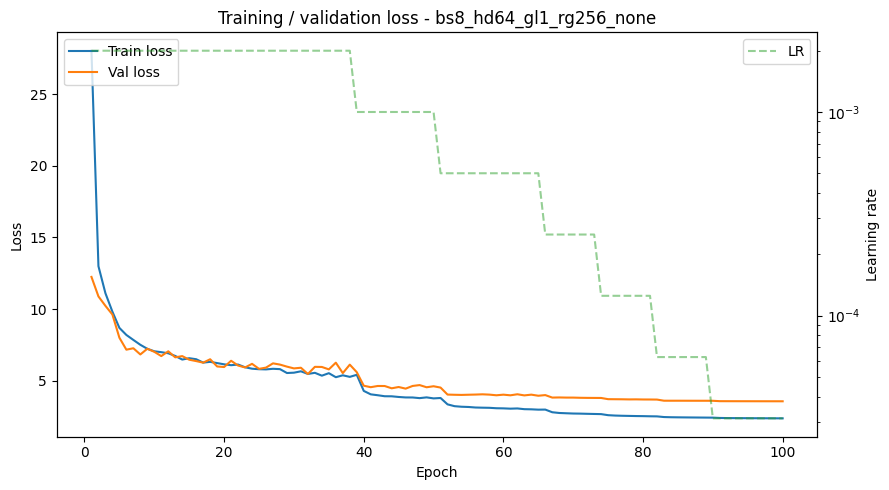

Best val loss 3.5704 | val RMSE 0.7900 | test RMSE 1.0320


In [42]:
plot_run(baseline)

## 9.4 Test Set Evaluation

Loss and RMSE on the test set, computed on the best checkpoint of the starting run (the test set is not used for any choice during training). The RMSE is in yards, averaged over valid players and frames. It is only a reference point: Chapter 10 searches for a better configuration from here.

In [43]:
print(f"Test loss: {baseline['test_loss']:.4f} | Test RMSE: {baseline['test_metric']:.4f} yards "
      f"(best validation RMSE: {baseline['best_val_metric']:.4f} yards)")

Test loss: 4.3852 | Test RMSE: 1.0320 yards (best validation RMSE: 0.7900 yards)


---
# 10. Sequential Hyperparameter Search

Five factors, searched **greedily**: each stage fixes whatever the previous stage(s) settled on, then explores the next factor around that point -- not a one-factor-at-a-time ablation against one shared fixed baseline. Order: global features, batch size, hidden dimension, GAT layers, regressor width.

Each stage's grid is run by `run_stage(runner, BASELINE, axis, grid)`, which prints a comparison table (validation/test RMSE, epochs actually trained, training time) and stops there -- it does **not** pick a winner on its own, because the lowest test RMSE is not automatically the right trade-off against how long or how much memory a configuration took. After reading the table, the next cell sets `BASELINE["<axis>"]` by hand to whichever value was chosen, before the stage after it runs. `BASELINE["global_mode"]` is the one exception: it is fixed to `"all"` in 10.1 by deliberate choice, not from reading a table.

Every run still gets its own label (`ExperimentRunner.make_label`, all five factors), so nothing here is lost or overwritten if the notebook restarts -- `runner.load_results()` above resumes exactly where a Colab session left off, and every run's best checkpoint is copied to `cfg.WEIGHTS_DIR` as soon as it is trained, not only the ones a stage ends up choosing.

10.6 reassembles the fully-optimized model and its batches for Chapter 11; the two extra checks of Chapter 12 (split size, an aggressive stress test) start from that same final `BASELINE`.

## 10.1 Global Features

`none` (the starting point above) removes the global branch entirely; `all` adds every global feature, including those that describe the outcome of the throw itself (ball landing point/travel, `expected_points_added`, `pass_result`...). Unlike every other factor below, `global_mode` is **not** chosen by reading the table: `all` is fixed as the search's global-features setting from here on by design, since it is by construction at least as informative as `none` -- this comparison only measures how much of the starting point's error the outcome information explains.

In [44]:
GLOBAL_MODE_GRID = ["none", "all"]

for mode in GLOBAL_MODE_GRID:
    runner.run(**{**BASELINE, "global_mode": mode}, verbose=True)

[bs8_hd64_gl1_rg256_none] already done (test RMSE 1.0320), skipped
[bs8_hd64_gl1_rg256_all] already done (test RMSE 0.9440), skipped


In [45]:
BASELINE["global_mode"] = "all"

## 10.2 Batch Size

Larger batches give a less noisy gradient and faster epochs, but fewer updates per epoch. Searched first among the remaining four factors because it only changes how the same graphs are grouped -- cheap to try before anything that changes the model itself. Weigh the table below by RMSE **and** by minutes: a slightly worse but much faster batch size can be the better choice if it lets you run more of the stages after this one.

In [46]:
BATCH_SIZE_GRID = [1, 8, 64]
run_stage(runner, BASELINE, "batch_size", BATCH_SIZE_GRID, verbose=True)

[bs1_hd64_gl1_rg256_all] already done (test RMSE 0.4642), skipped
[bs8_hd64_gl1_rg256_all] already done (test RMSE 0.9440), skipped
[bs64_hd64_gl1_rg256_all] already done (test RMSE 1.6006), skipped
 batch_size  val RMSE  test RMSE  epochs   minutes
          1  0.431266   0.464224     100 48.677027
          8  0.701436   0.943955     100  9.814904
         64  0.891868   1.600553     100  3.957194


,batch_size,val RMSE,test RMSE,epochs,minutes
0,1,0.431266,0.464224,100,48.677027
1,8,0.701436,0.943955,100,9.814904
2,64,0.891868,1.600553,100,3.957194


In [47]:
BASELINE["batch_size"] = 1   # edit: set to the value you pick from the table above

## 10.3 Hidden Dimension

The hidden dimension sets the size of the embeddings of the encoder (`hidden_dim - 2`), of the global branch and of the regressor input. The cell first prints the number of parameters of each size, to relate capacity, RMSE and training time before picking.

In [48]:
HIDDEN_DIM_GRID = [8, 64, 256]

for hd in HIDDEN_DIM_GRID:
    n_params = sum(p.numel() for p in make_model(global_in_dim, hd, BASELINE["gat_num_layers"],
                                                 BASELINE["regressor_hidden_dim"]).parameters())
    print(f"hidden_dim={hd:>4}: {n_params:>10,} parameters")

hidden_dim=   8:     51,316 parameters
hidden_dim=  64:     75,620 parameters
hidden_dim= 256:    206,564 parameters


In [49]:
run_stage(runner, BASELINE, "hidden_dim", HIDDEN_DIM_GRID, verbose= True)

[bs1_hd8_gl1_rg256_all] already done (test RMSE 0.5298), skipped
[bs1_hd64_gl1_rg256_all] already done (test RMSE 0.4642), skipped
[bs1_hd256_gl1_rg256_all] already done (test RMSE 0.5156), skipped
 hidden_dim  val RMSE  test RMSE  epochs   minutes
          8  0.497387   0.529848     100 51.384223
         64  0.431266   0.464224     100 48.677027
        256  0.485146   0.515644     100 47.807066


,hidden_dim,val RMSE,test RMSE,epochs,minutes
0,8,0.497387,0.529848,100,51.384223
1,64,0.431266,0.464224,100,48.677027
2,256,0.485146,0.515644,100,47.807066


In [50]:
BASELINE["hidden_dim"] = 64

## 10.4 Regressor Width

Hidden size of the final per-player regressor (8.3), the two-layer MLP that turns each player's last embedding into `MAX_OUTPUT_FRAMES` future positions. The last stage of the search: once you set `BASELINE["regressor_hidden_dim"]` below, `BASELINE` holds your fully-chosen configuration (all five factors) in one place. If the value you pick was one of `REGRESSOR_HIDDEN_DIM_GRID`, 10.6 reloads it instantly (already trained); if you pick something else, 10.6 trains it fresh.

In [51]:
REGRESSOR_HIDDEN_DIM_GRID = [64, 256, 512]

for rg in REGRESSOR_HIDDEN_DIM_GRID:
    n_params = sum(p.numel() for p in make_model(global_in_dim, BASELINE["hidden_dim"],
                                                 BASELINE["gat_num_layers"], rg).parameters())
    print(f"regressor_hidden_dim={rg:>4}: {n_params:>10,} parameters")

regressor_hidden_dim=  64:     27,044 parameters
regressor_hidden_dim= 256:     75,620 parameters
regressor_hidden_dim= 512:    140,388 parameters


In [52]:
run_stage(runner, BASELINE, "regressor_hidden_dim", REGRESSOR_HIDDEN_DIM_GRID, verbose= True)

[bs1_hd64_gl1_rg64_all] already done (test RMSE 0.4828), skipped
[bs1_hd64_gl1_rg256_all] already done (test RMSE 0.4642), skipped
[bs1_hd64_gl1_rg512_all] already done (test RMSE 0.4710), skipped
 regressor_hidden_dim  val RMSE  test RMSE  epochs   minutes
                   64  0.453999   0.482818     100 48.658895
                  256  0.431266   0.464224     100 48.677027
                  512  0.441709   0.471048     100 49.209159


,regressor_hidden_dim,val RMSE,test RMSE,epochs,minutes
0,64,0.453999,0.482818,100,48.658895
1,256,0.431266,0.464224,100,48.677027
2,512,0.441709,0.471048,100,49.209159


In [53]:
BASELINE["regressor_hidden_dim"] = 256

## 10.5 GAT Layers

Depth of each spatio-temporal attention branch (8.2): stacking more `GATEncoder` layers lets a node's embedding reach farther across the play graph (one extra hop of neighbours per layer), at the cost of one more sequential message-passing call per branch -- with small batch sizes this is mostly a wall-clock cost, not a parameter-count one, as the print below and the `minutes` column of the table make visible.

In [54]:
GAT_NUM_LAYERS_GRID = [1, 2, 3]

for gl in GAT_NUM_LAYERS_GRID:
    n_params = sum(p.numel() for p in make_model(global_in_dim, BASELINE["hidden_dim"], gl,
                                                 BASELINE["regressor_hidden_dim"]).parameters())
    print(f"gat_num_layers={gl}: {n_params:>10,} parameters")

gat_num_layers=1:     75,620 parameters
gat_num_layers=2:     78,528 parameters
gat_num_layers=3:     81,436 parameters


In [55]:
run_stage(runner, BASELINE, "gat_num_layers", GAT_NUM_LAYERS_GRID, verbose= True)

[bs1_hd64_gl1_rg256_all] already done (test RMSE 0.4642), skipped
[bs1_hd64_gl2_rg256_all] already done (test RMSE 0.4736), skipped
[bs1_hd64_gl3_rg256_all] already done (test RMSE 0.4541), skipped
 gat_num_layers  val RMSE  test RMSE  epochs   minutes
              1  0.431266   0.464224     100 48.677027
              2  0.438978   0.473589     100 67.447212
              3  0.420640   0.454066     100 85.116183


,gat_num_layers,val RMSE,test RMSE,epochs,minutes
0,1,0.431266,0.464224,100,48.677027
1,2,0.438978,0.473589,100,67.447212
2,3,0.420640,0.454066,100,85.116183


In [56]:
BASELINE["gat_num_layers"] = 1   # picked: best test RMSE in 10.5's table (0.454 vs 0.464 at gl=1), despite the extra training time

## 10.6 Assembling the Final Model

`BASELINE` now holds whatever you chose at every stage. If every value was one already tried in that stage's grid, the run below reloads an existing checkpoint instantly; otherwise it trains that exact combination now. Chapter 11's predicted trajectories and global-branch diagnostics need the actual model object and the batches built at this same `(batch_size, global_mode)`, not the starting point's -- `train_batches`/`test_batches` are rebuilt here (`BatchProvider` caches one combination at a time, so this is free if it is the same one 10.5 just used).

In [57]:
print("Final configuration:", BASELINE)

Final configuration: {'batch_size': 1, 'hidden_dim': 64, 'global_mode': 'all', 'gat_num_layers': 1, 'regressor_hidden_dim': 256}


In [65]:
final = runner.run(**BASELINE, keep_model=True)
model = final["model"]

train_batches, val_batches, test_batches, global_in_dim = batches.get(BASELINE["batch_size"], BASELINE["global_mode"])
x_global_train = torch.cat([b.x_global for b in train_batches], dim=0)
sample_train_batch = train_batches[0]
del train_batches, val_batches

print(f"Final test RMSE: {final['test_metric']:.4f} yards (starting point was {baseline['test_metric']:.4f} yards)")

[bs1_hd64_gl1_rg256_all] already done, model reloaded from weights/best_model_bs1_hd64_gl1_rg256_all.pt
Final test RMSE: 0.4642 yards (starting point was 1.0320 yards)


---
# 11. Results

Performance of every configuration tried during the search, from the summary table to the single predicted trajectories. All the numbers are RMSE in yards on valid players and frames; validation is used to choose the checkpoint, test is the number to report. `BASELINE` here is the *final*, fully-optimized configuration found in Chapter 10, not the Chapter 9 starting point.

11.1-11.3 read from `results` (below), loaded with `load_all_results` -- point it at one `experiment_results.json` or several (e.g. one per Colab session; see 11.0): everything through 11.3 needs nothing but that file, no model, no GPU, no re-running Chapters 1-9. Only 11.4-11.5 (predicted trajectories, global-branch diagnostics) need the real model and data, since they run an actual forward pass.

In [58]:
# The search (Chapter 10) is complete: `experiment_results_updated.json` is the final, reconciled set -- one
# row per configuration. Two configs were trained twice across separate Colab sessions during the search
# (bs8_hd64_gl1_rg256_none, bs8_hd64_gl1_rg256_all); only the better test RMSE of each was kept here. If you
# collect another session later, add its file below -- `load_all_results` still keeps every source's rows
# separate rather than merging them, so nothing here has to change to support that.
RESULTS_SOURCES = {
    "final": cfg.OUTPUT_DIR / "experiment_results.json",
}
results = load_all_results(RESULTS_SOURCES)
print(f"{len(results)} runs loaded from {len(RESULTS_SOURCES)} source(s).")

11 runs loaded from 1 source(s).


## 11.0 Progress Check (optional, no retraining)

Everything below in 11.1-11.3 also works with `baseline=None` instead of the final `BASELINE` -- each study is then read against its own local reference point, auto-detected directly from `results` as whichever configuration was actually held fixed while that study's axis was varied (the same idea `run_stage`'s live table uses, generalized to read it back later from the saved json instead of only live during the run). That makes this section usable at ANY point in the search, complete or not: after a Colab disconnect, halfway through 10.3, or merging in a second session's `experiment_results.json` that covered stages this one hasn't reached yet -- as long as `results` has at least two runs for a given axis with everything else matching, that axis's panel appears. A run whose label is shared between two studies (the point one stage carried over to the next) is outlined, the closest thing to "the baseline" when no single final configuration has been fixed yet.

In [63]:
show_summary_table(results, baseline=None)

KeyError: '`Styler.apply` and `.map` are not compatible with non-unique index or columns.'

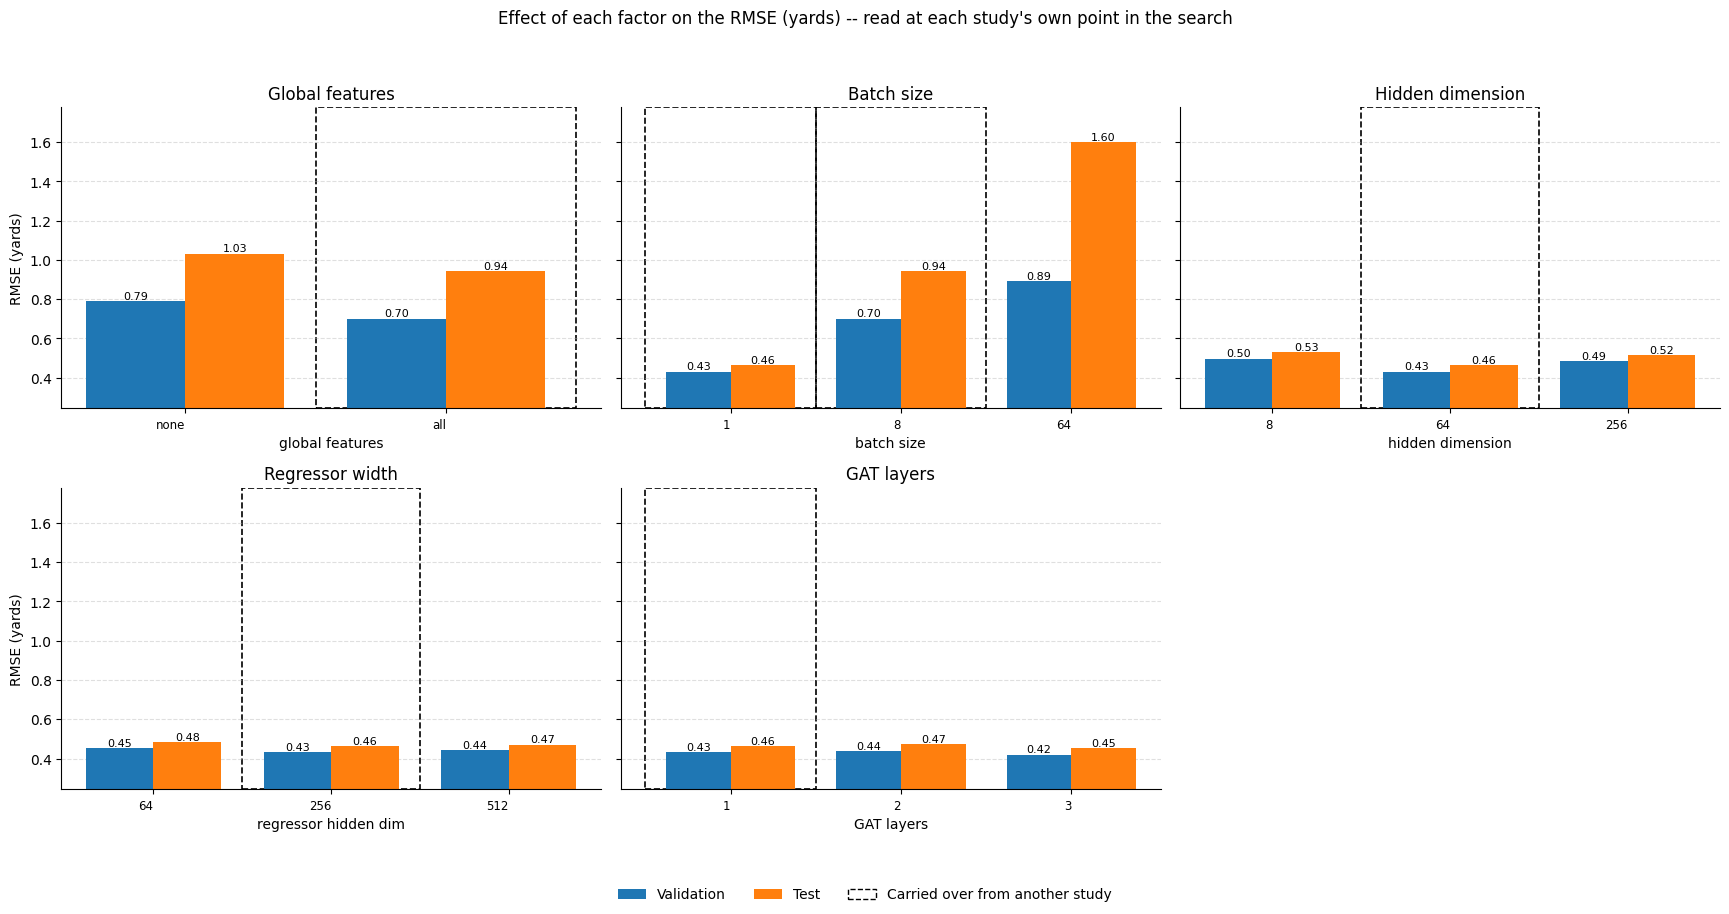

No final BASELINE given: each study below is read against its OWN local reference point (the configuration actually held fixed while that study ran), the same way run_stage's live table does -- this works whether or not the search has finished.

Global features (tried: none, all): best is all with test RMSE 0.944 yards.
Batch size (tried: 1, 8, 64): best is 1 with test RMSE 0.464 yards.
Hidden dimension (tried: 8, 64, 256): best is 64 with test RMSE 0.464 yards.
Regressor width (tried: 64, 256, 512): best is 256 with test RMSE 0.464 yards.
GAT layers (tried: 1, 2, 3): best is 3 with test RMSE 0.454 yards.


In [ ]:
plot_ablations(results, baseline=None)
print_takeaways(results, baseline=None)

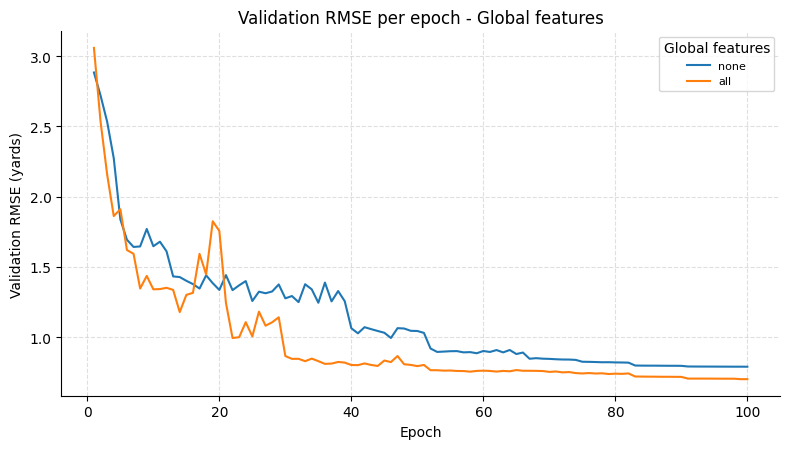

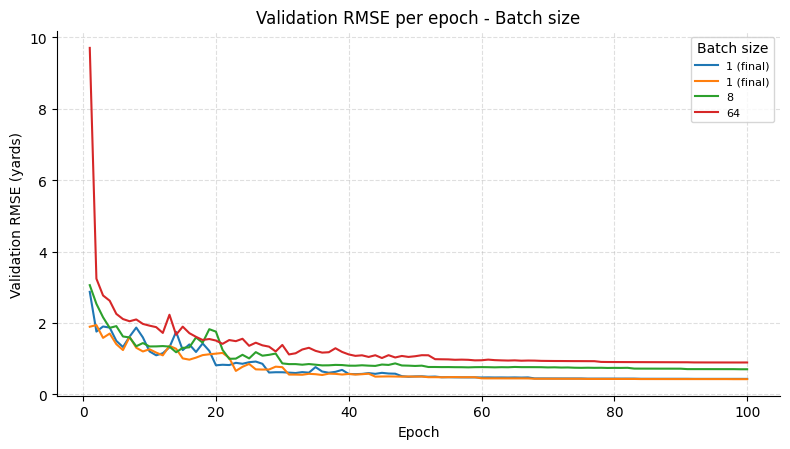

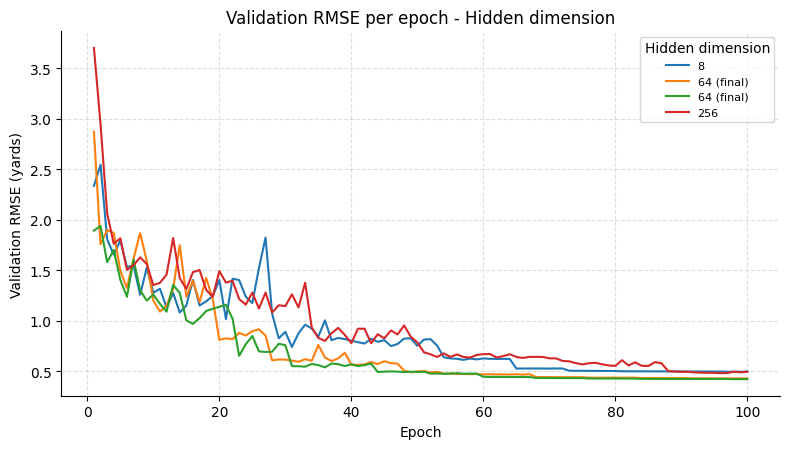

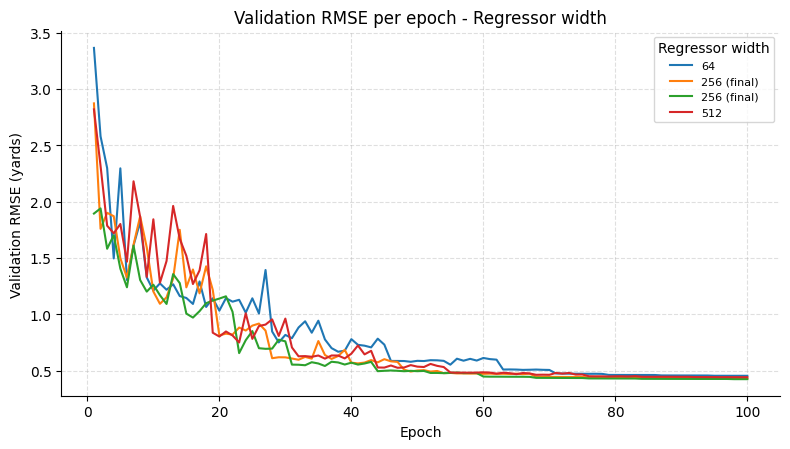

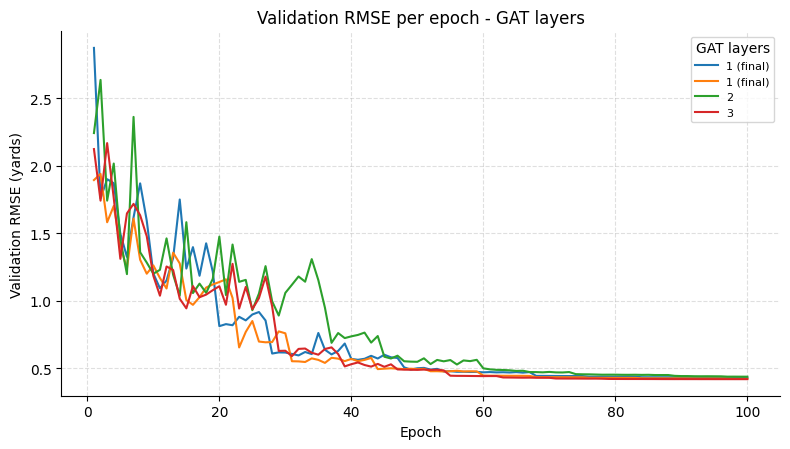

In [60]:
for axis in STUDIES:
    plot_learning_curves(results, None, axis)

## 11.1 Comparison Table

One row per configuration, grouped by study; the baseline (the final configuration) appears in each study it belongs to. Because the search is sequential rather than one-factor-at-a-time (10.1-10.5), only the **last** stage run (regressor width, 10.5) is guaranteed to have every other factor already at its final value -- the batch size / hidden dimension / GAT layers studies below were run with the *not-yet-final* value of factors decided in later stages, so their own rows may not all satisfy "every other factor at the final `BASELINE`" and can appear incomplete here. The authoritative record of what each stage actually compared is the small table `run_stage` printed live in that stage's cell (10.2-10.5) -- this table is a convenient global summary, not the source of truth for the sequential trace. For a version of this table that reads each study at its own point in the search instead (no incomplete rows), see 11.0.

Columns: validation and test RMSE, the difference of the test RMSE from the (final) baseline (negative is better), the epochs actually trained (early stopping) and the training time. In bold the best test RMSE of each study that has any matching rows.

In [66]:
show_summary_table(results, baseline= None)

KeyError: '`Styler.apply` and `.map` are not compatible with non-unique index or columns.'

## 11.2 Effect of Each Factor

Validation (blue) and test (orange) RMSE of each configuration, one panel per study; the dashed frame marks the (final) baseline. The panels share the y axis, so the height of the bars is comparable between studies. See 11.1's caveat: a panel can be sparse if its stage was run before later stages had picked their final value.

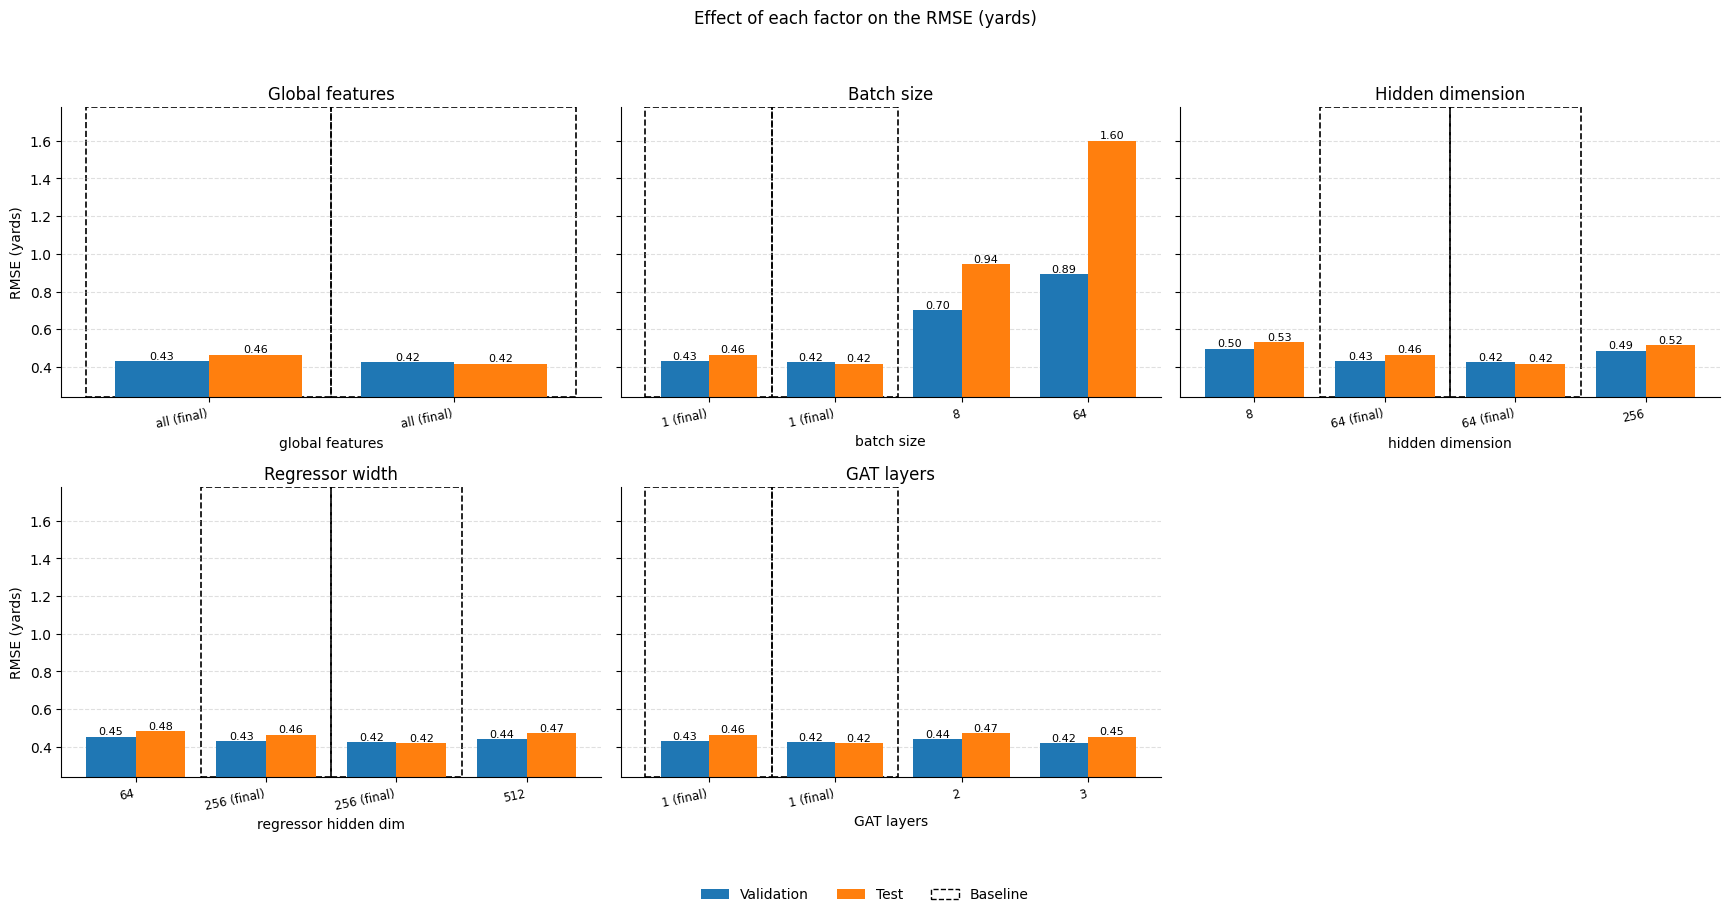

Baseline (batch size 1, hidden dim 64, global features 'all', 1 GAT layer(s), regressor width 256): test RMSE 0.464 yards

Global features (tried: all (final), all (final)): the baseline is the best configuration.
Batch size (tried: 1 (final), 1 (final), 8, 64): the baseline is the best configuration.
Hidden dimension (tried: 8, 64 (final), 64 (final), 256): the baseline is the best configuration.
Regressor width (tried: 64, 256 (final), 256 (final), 512): the baseline is the best configuration.
GAT layers (tried: 1 (final), 1 (final), 2, 3): the baseline is the best configuration.


In [67]:
plot_ablations(results, BASELINE)
print_takeaways(results, BASELINE)

## 11.3 Learning Curves

Validation RMSE per epoch of every run that matches the final baseline on the other factors (see 11.1), one figure per study, with the baseline in bold. They show how fast each configuration learns and where it stops (early stopping), not just who ends up best.

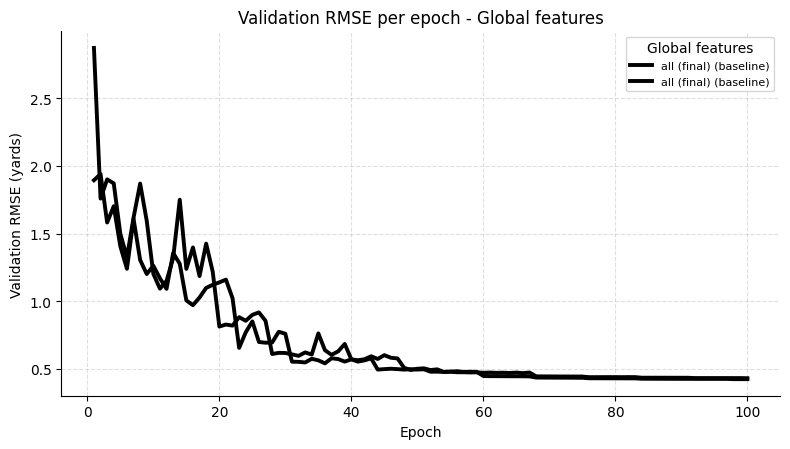

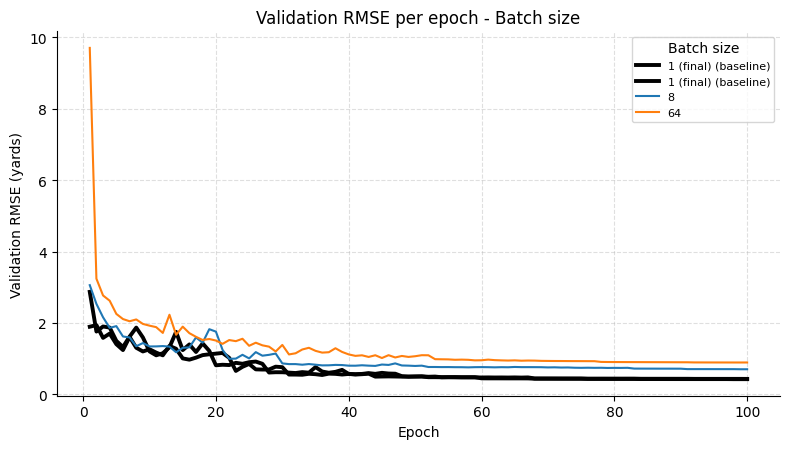

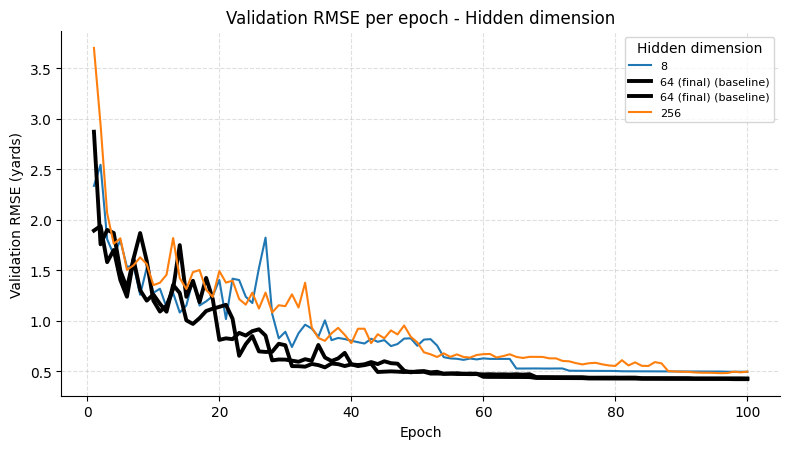

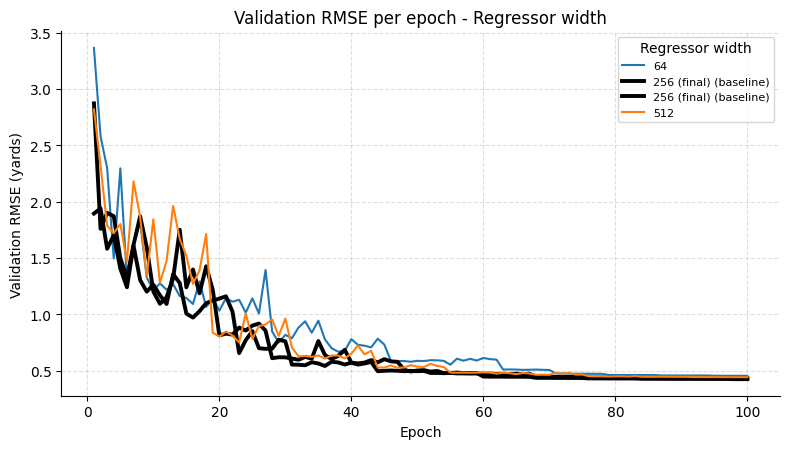

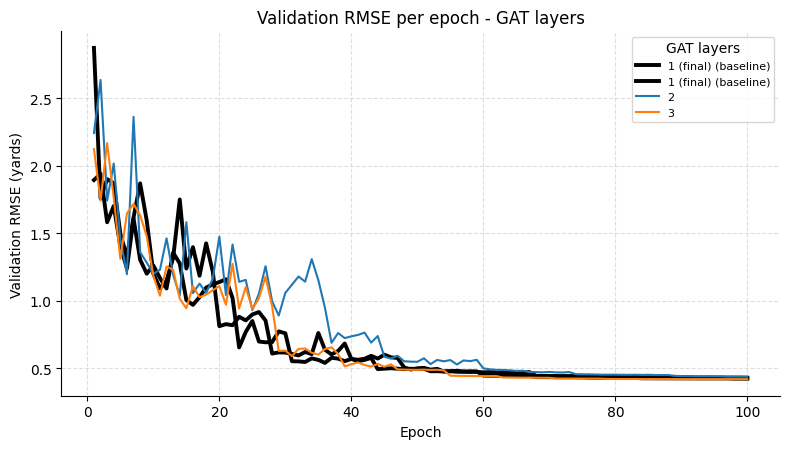

In [68]:
for axis in STUDIES:
    plot_learning_curves(results, BASELINE, axis)

## 11.4 Predicted Trajectories

Ground truth against the prediction of the final model for three plays of the test set. The faint lines are the observed pre-pass trajectories, the solid light lines the real post-pass trajectories, the dark lines the prediction (after Savitzky-Golay smoothing computed together with the observed past); blue is the offense, red the defense, the orange dot is the landing point of the ball. The two end markers of a player are the real and predicted final positions: their distance is the final displacement error. The printed lines give the MSE of each player before and after the smoothing.

Player 3: MSE before smoothing 0.084 | after 0.079
Player 10: MSE before smoothing 0.074 | after 0.087


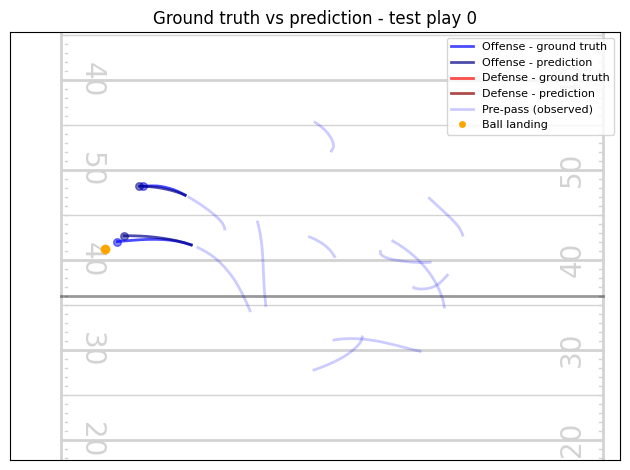

Player 11: MSE before smoothing 0.230 | after 0.255


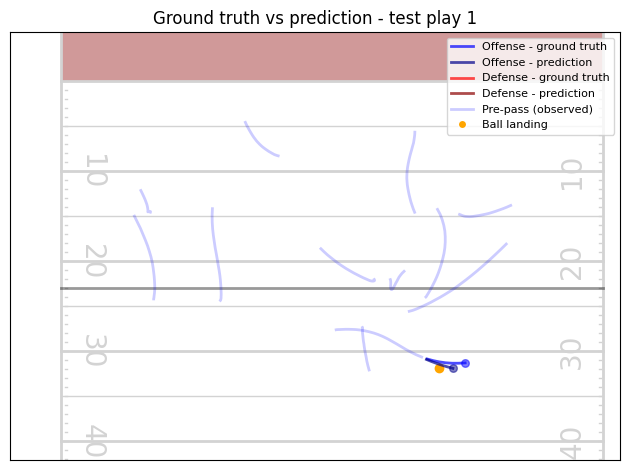

Player 0: MSE before smoothing 0.079 | after 0.085
Player 3: MSE before smoothing 0.459 | after 0.471
Player 4: MSE before smoothing 0.027 | after 0.021
Player 11: MSE before smoothing 0.003 | after 0.009


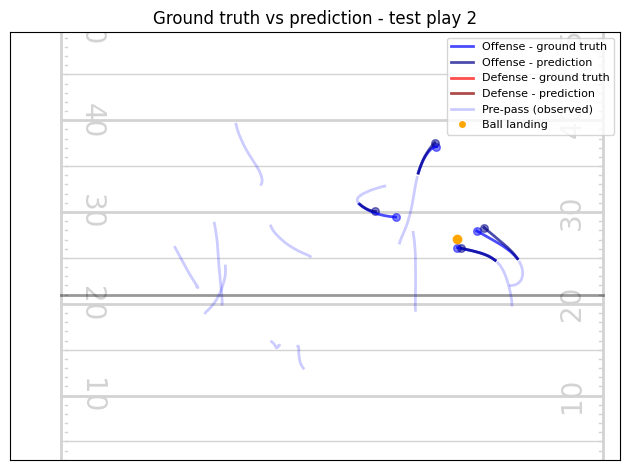

Player 0: MSE before smoothing 0.201 | after 0.240
Player 1: MSE before smoothing 0.006 | after 0.014
Player 4: MSE before smoothing 0.011 | after 0.006
Player 5: MSE before smoothing 0.007 | after 0.009
Player 12: MSE before smoothing 0.021 | after 0.027


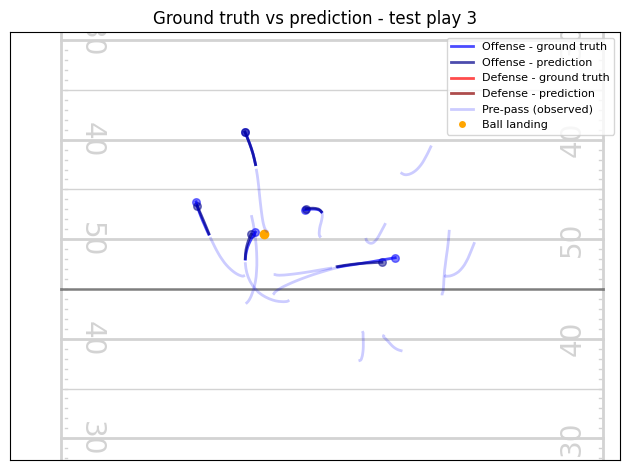

Player 2: MSE before smoothing 0.147 | after 0.163
Player 9: MSE before smoothing 0.370 | after 0.391


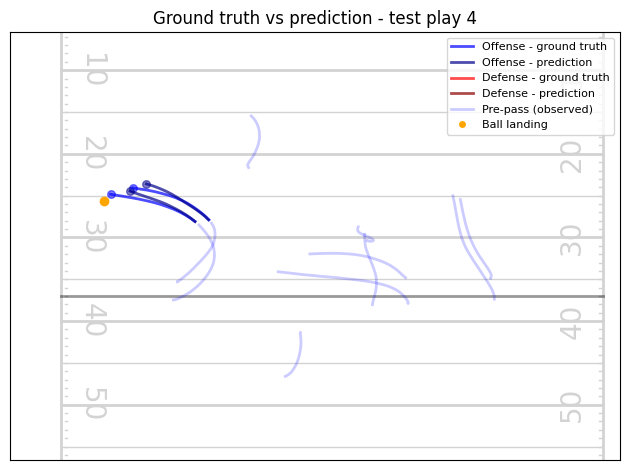

Player 1: MSE before smoothing 0.476 | after 0.473
Player 2: MSE before smoothing 1.143 | after 1.128
Player 3: MSE before smoothing 0.090 | after 0.087
Player 6: MSE before smoothing 0.820 | after 0.821
Player 10: MSE before smoothing 0.057 | after 0.058


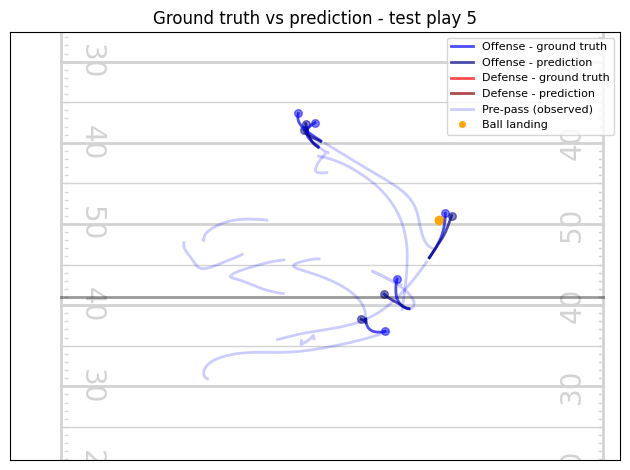

Player 0: MSE before smoothing 0.081 | after 0.081
Player 1: MSE before smoothing 0.088 | after 0.113
Player 2: MSE before smoothing 0.793 | after 0.795
Player 3: MSE before smoothing 0.657 | after 0.637
Player 6: MSE before smoothing 0.056 | after 0.054


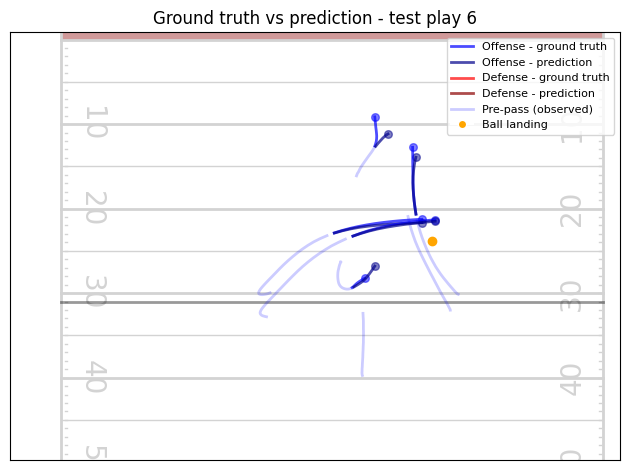

Player 6: MSE before smoothing 0.015 | after 0.015
Player 12: MSE before smoothing 0.025 | after 0.042


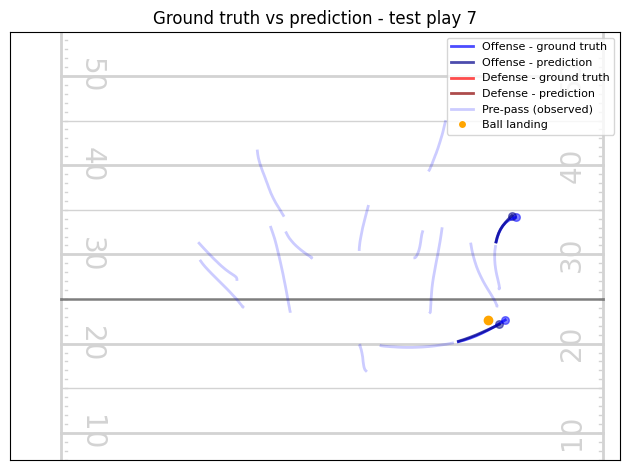

Player 0: MSE before smoothing 0.043 | after 0.050
Player 1: MSE before smoothing 0.039 | after 0.049
Player 3: MSE before smoothing 0.121 | after 0.144
Player 11: MSE before smoothing 0.140 | after 0.151


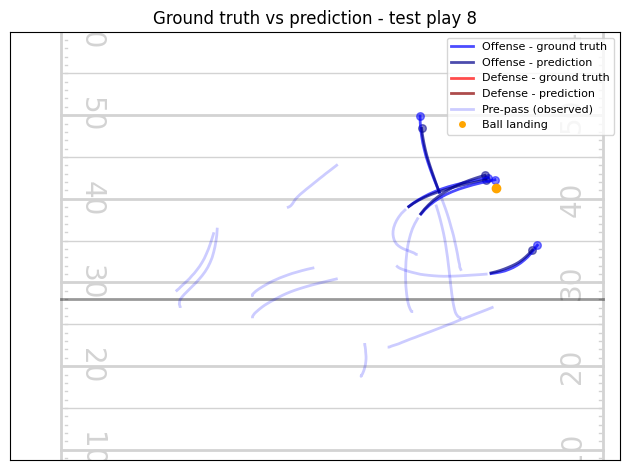

Player 4: MSE before smoothing 0.076 | after 0.078
Player 5: MSE before smoothing 0.008 | after 0.009
Player 6: MSE before smoothing 0.009 | after 0.015
Player 11: MSE before smoothing 0.013 | after 0.012


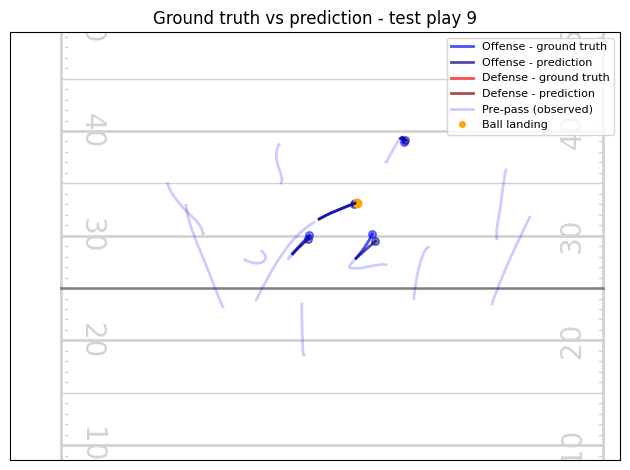

Player 1: MSE before smoothing 0.015 | after 0.018
Player 2: MSE before smoothing 0.009 | after 0.007
Player 12: MSE before smoothing 0.023 | after 0.018


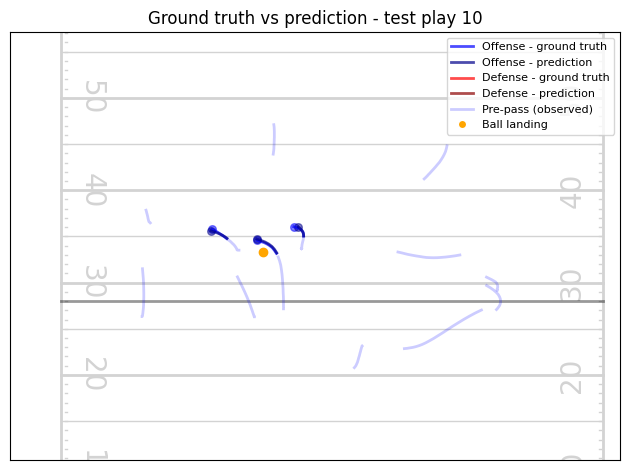

Player 5: MSE before smoothing 0.929 | after 0.923
Player 6: MSE before smoothing 0.910 | after 0.881
Player 7: MSE before smoothing 2.486 | after 2.400
Player 13: MSE before smoothing 0.128 | after 0.122


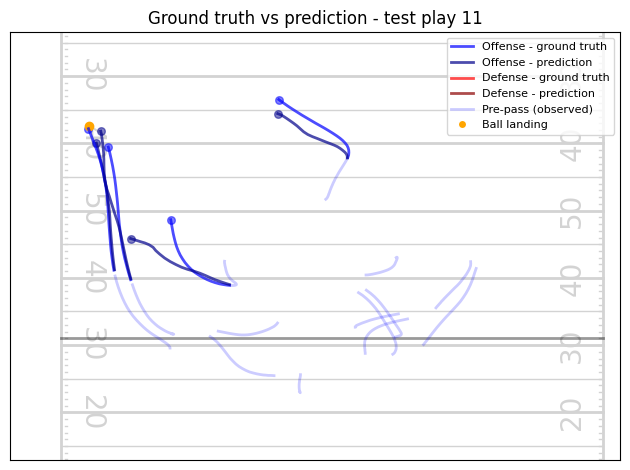

Player 0: MSE before smoothing 0.021 | after 0.026
Player 12: MSE before smoothing 0.006 | after 0.007


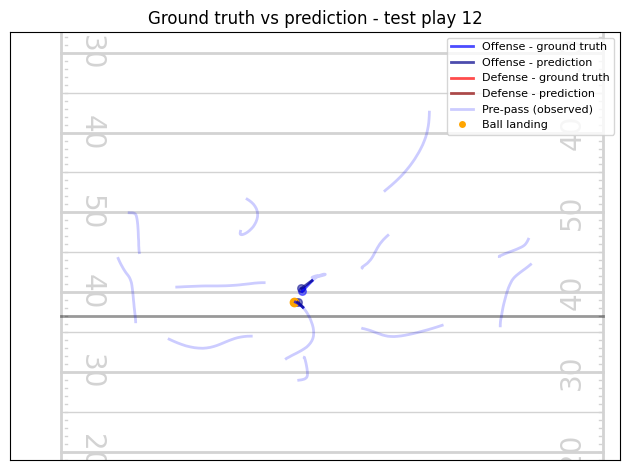

Player 0: MSE before smoothing 0.541 | after 0.509
Player 3: MSE before smoothing 0.005 | after 0.006
Player 12: MSE before smoothing 0.158 | after 0.153


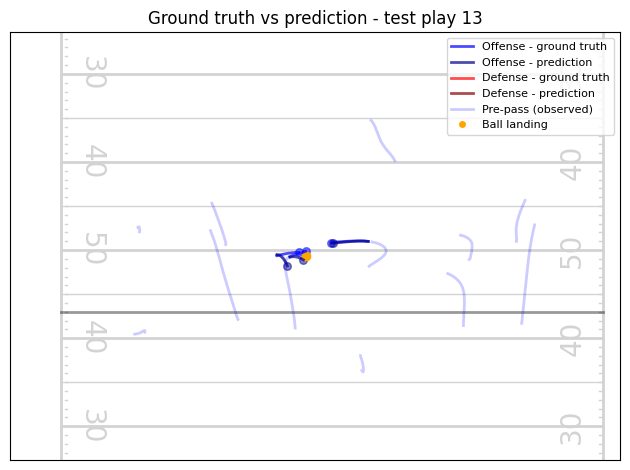

Player 1: MSE before smoothing 1.619 | after 1.612
Player 3: MSE before smoothing 0.645 | after 0.646
Player 4: MSE before smoothing 1.788 | after 1.810
Player 6: MSE before smoothing 0.175 | after 0.192
Player 12: MSE before smoothing 0.690 | after 0.713


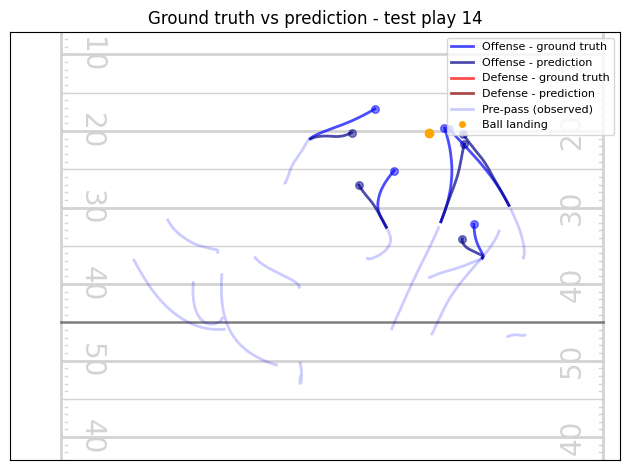

Player 2: MSE before smoothing 0.502 | after 0.491
Player 5: MSE before smoothing 3.324 | after 3.299
Player 12: MSE before smoothing 0.543 | after 0.548


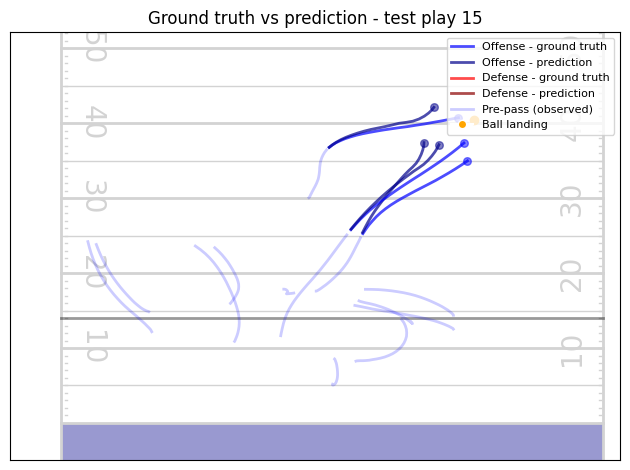

Player 4: MSE before smoothing 0.040 | after 0.042
Player 12: MSE before smoothing 0.007 | after 0.007


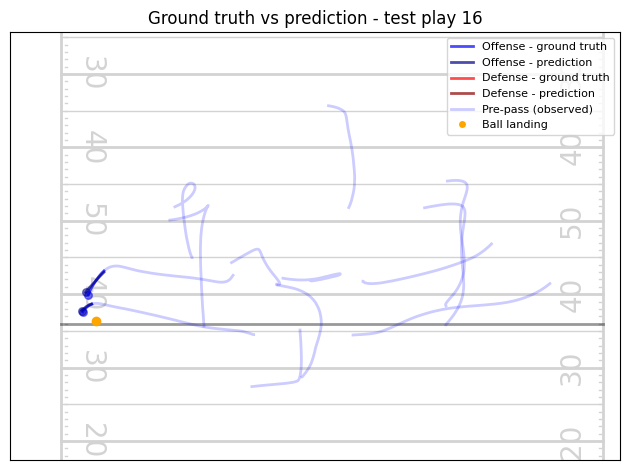

Player 6: MSE before smoothing 0.056 | after 0.065
Player 12: MSE before smoothing 0.099 | after 0.107


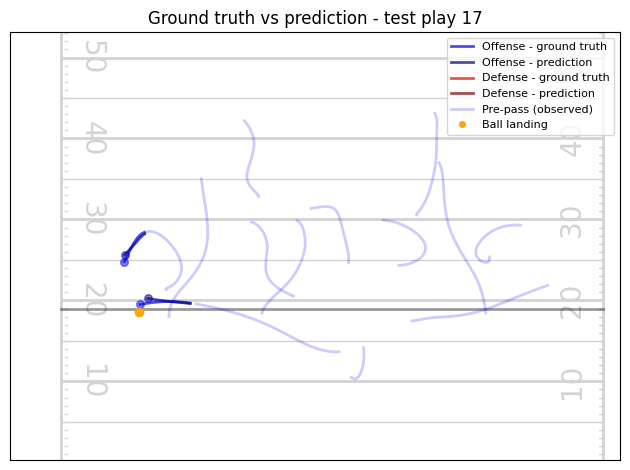

Player 1: MSE before smoothing 0.332 | after 0.345
Player 2: MSE before smoothing 0.581 | after 0.543
Player 4: MSE before smoothing 0.393 | after 0.383
Player 12: MSE before smoothing 0.102 | after 0.085


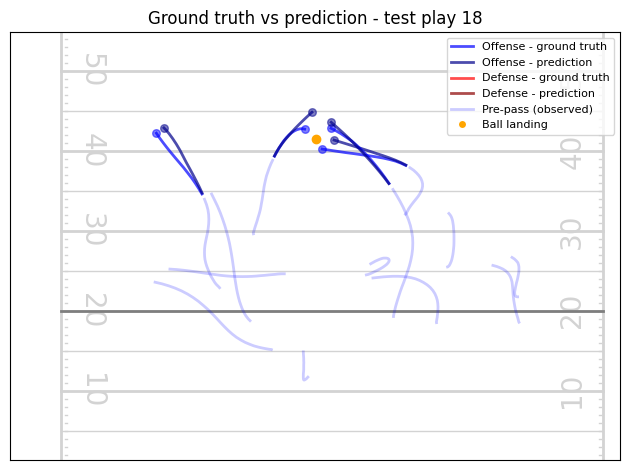

Player 12: MSE before smoothing 0.010 | after 0.021


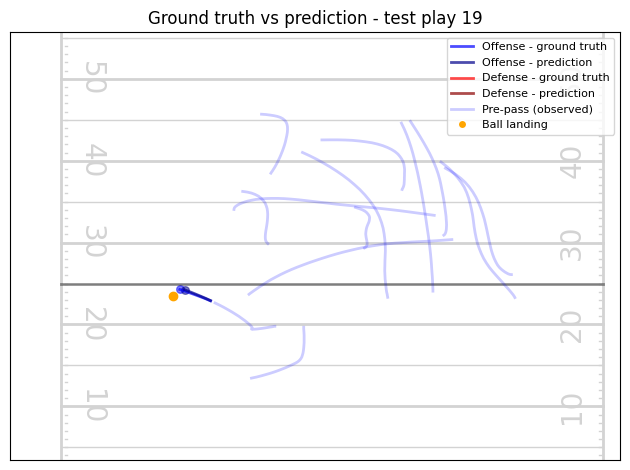

In [ ]:
show_predictions(model, test_batches, device, GLOBAL_FEATURE_MINMAX, n_plays=20)

## 11.5 Diagnostics of the Global Branch

Does the global branch actually weigh on the prediction? For each global feature the table gives its scale on the train set (`std`), the mean absolute weight of the projection layer and their product, the effective contribution (a feature with a very large scale can dominate the input even with a small weight). The last lines compare the size of the global embedding with that of the spatio-temporal one: if the first is much smaller, the global features are diluted whatever they contain. It is computed on the final model (10.6), which is the one with all the global features (`global_mode="all"` was fixed in 10.1).

In [69]:
feature_names = global_feature_names(data, get_ball_stats)
feat_stats = global_branch_diagnostics(model, x_global_train, sample_train_batch, feature_names, device)

                          feature     mean      std      min      max  mean_abs_weight  effective_contribution
                ball_at_landing_y 0.489914 0.243941 0.024645 0.960822         0.590409                0.144025
    route_of_targeted_receiver_GO 0.108667 0.311272 0.000000 1.000000         0.255980                0.079679
 route_of_targeted_receiver_HITCH 0.177000 0.381732 0.000000 1.000000         0.197117                0.075246
   route_of_targeted_receiver_OUT 0.167333 0.373335 0.000000 1.000000         0.190876                0.071261
  route_of_targeted_receiver_FLAT 0.152667 0.359726 0.000000 1.000000         0.171370                0.061646
                    ball_travel_y 0.496013 0.166349 0.123095 0.929446         0.367638                0.061156
    route_of_targeted_receiver_IN 0.074000 0.261815 0.000000 1.000000         0.220269                0.057670
  route_of_targeted_receiver_POST 0.049000 0.215904 0.000000 1.000000         0.242724                0.052405
r

---
# 12. Split-Size Check and a Stress Test

Two more experiments, run only after Chapter 10's search has produced a final `BASELINE`: neither is a stage of that search, so both are kept separate from it.

## 12.1 Same Configuration, Larger Split

Retrains the exact final `BASELINE` on `N_TRAIN=6000, N_VAL=2000, N_TEST=2000` ("10k", double the "5k" split used throughout Chapters 9-10) to check whether the search's winner still holds with more data. A single comparison point: rebuilding `BatchProvider` on 10000 plays instead of 5000 is itself expensive, so this is not a repeat of the whole search.

In [70]:
from dataclasses import replace

# WEIGHTS_DIR is overridden too, not just OUTPUT_DIR: run_training() mirrors every checkpoint to
# cfg.WEIGHTS_DIR/f"best_model_{run_label}.pt", and make_label() does NOT encode split size -- with the
# same BASELINE dict, this run's label is identical to the Chapter 10.6 final model's ("bs1_hd64_gl3_rg256_all").
# Left pointed at the default WEIGHTS_DIR=Path("weights"), this run would silently overwrite the real final
# model's checkpoint the moment it finishes training. Keeping this split's weights in their own folder avoids
# that entirely, and also keeps 12.1 and 12.2 (same label again) from overwriting each other.
cfg_10k = replace(cfg, N_TRAIN=6000, N_VAL=2000, N_TEST=2000,
                  OUTPUT_DIR=Path("outputs"), WEIGHTS_DIR=Path("weights"))

# Same data (already loaded): only the sampled pool and the train/val/test split change size.
play_lengths_10k = compute_play_lengths(data, cfg_10k)
splits_10k = make_splits(play_lengths_10k, cfg_10k)
batches_10k = BatchProvider(data, splits_10k, cfg_10k,
                            preprocess_play_fn=lambda game, play: preprocess_play(data, game, play),
                            global_features_fn=get_global_features)

runner_10k = ExperimentRunner(cfg_10k, batches_10k, make_model, loss_fn=masked_loss, metric_fn=masked_rmse,
                              device=device, results_path=cfg_10k.OUTPUT_DIR / "experiment_results.json")
#runner_10k.load_results()


Sampled pool: 10000 plays (covering 225/225 length bins)
train=6000  val=2000  test=2000


In [83]:
split_check_10k = runner_10k.run(**BASELINE, verbose=True, keep_model=False)

print(f"\nsplit  5k (3000/1000/1000): test RMSE {final['test_metric']:.4f} yards")
print(f"split 10k (6000/2000/2000): test RMSE {split_check_10k['test_metric']:.4f} yards")


Processing Train:   0%|          | 0/6000 [00:00<?, ?it/s]

Graphs Train (all):   0%|          | 0/6000 [00:00<?, ?it/s]

Processing Validation:   0%|          | 0/2000 [00:00<?, ?it/s]

Graphs Validation (all):   0%|          | 0/2000 [00:00<?, ?it/s]

Processing Test:   0%|          | 0/2000 [00:00<?, ?it/s]

Graphs Test (all):   0%|          | 0/2000 [00:00<?, ?it/s]


[bs1_hd64_gl1_rg256_all] Epoch 1/100
Best model saved
Train Loss: 14.7277 | Val Loss: 8.9604 | Val Metric: 1.8936 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 2/100
Best model saved
Train Loss: 8.3494 | Val Loss: 8.5822 | Val Metric: 1.9393 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 3/100
Best model saved
Train Loss: 7.1434 | Val Loss: 6.8216 | Val Metric: 1.5814 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 4/100
Train Loss: 6.7156 | Val Loss: 7.3435 | Val Metric: 1.7019 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 5/100
Best model saved
Train Loss: 6.2897 | Val Loss: 6.8212 | Val Metric: 1.4049 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 6/100
Best model saved
Train Loss: 6.0809 | Val Loss: 5.7219 | Val Metric: 1.2395 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 7/100
Train Loss: 5.8765 | Val Loss: 7.4081 | Val Metric: 1.6082 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 8/100
Train Loss: 5.7291 | Val Loss: 6.0142 | Val Metric: 1.3041 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] 

## 12.2 Off-Script: Aggressive Large-Batch Run

One single, deliberately expensive run: the final `BASELINE`, tuned to high values -- a batch size close to "full-batch" -- on whichever split `OFFSCRIPT_RUNNER` below points at. This is exploratory, not part of the search: a batch this large already covers a big share of the training set in one step, which changes the gradient noise a lot, and with padded per-play tensors (`MAX_INPUT_FRAMES=123`, `MAX_INPUT_NODES=17`) it can also be very memory-hungry, unlike the small batch sizes tried in 10.2. Start lower than the true full-batch size and raise it only if memory allows.

In [71]:
from dataclasses import replace

# Same isolation as 12.1's cfg_10k, and its own WEIGHTS_DIR distinct from BOTH the main "weights" folder and
# "weights_split10k" -- this run's label (with BASELINE unchanged) still collides with 12.1's, so it must not
# share a weights folder with it either.
cfg_14k = replace(cfg, BATCH_SIZE=8, N_TRAIN=9000, N_VAL=2500, N_TEST=2500,
                  OUTPUT_DIR=Path("outputs"), WEIGHTS_DIR=Path("weights"))

# Same data (already loaded): only the sampled pool and the train/val/test split change size.
play_lengths_14k = compute_play_lengths(data, cfg_14k)
splits_14k = make_splits(play_lengths_14k, cfg_14k)
batches_14k = BatchProvider(data, splits_14k, cfg_14k,
                            preprocess_play_fn=lambda game, play: preprocess_play(data, game, play),
                            global_features_fn=get_global_features)

runner_14k = ExperimentRunner(cfg_14k, batches_14k, make_model, loss_fn=masked_loss, metric_fn=masked_rmse,
                              device=device, results_path=cfg_14k.OUTPUT_DIR / "experiment_results.json")
#runner_14k.load_results()


Sampled pool: 14000 plays (covering 225/225 length bins)
train=9000  val=2500  test=2500


In [72]:
split_check_14k = runner_14k.run(**BASELINE, verbose=True, keep_model=False)

print(f"\nsplit  5k (3000/1000/1000): test RMSE {final['test_metric']:.4f} yards")
print(f"split 14k (9000/2500/2500): test RMSE {split_check_14k['test_metric']:.4f} yards")


Processing Train:   0%|          | 0/9000 [00:00<?, ?it/s]

Graphs Train (all):   0%|          | 0/9000 [00:00<?, ?it/s]

Processing Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Graphs Validation (all):   0%|          | 0/2500 [00:00<?, ?it/s]

Processing Test:   0%|          | 0/2500 [00:00<?, ?it/s]

Graphs Test (all):   0%|          | 0/2500 [00:00<?, ?it/s]


[bs1_hd64_gl1_rg256_all] Epoch 1/100
Best model saved
Train Loss: 12.9068 | Val Loss: 7.2234 | Val Metric: 1.5260 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 2/100
Best model saved
Train Loss: 7.6047 | Val Loss: 7.1855 | Val Metric: 1.5027 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 3/100
Best model saved
Train Loss: 6.6826 | Val Loss: 5.6234 | Val Metric: 1.2391 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 4/100
Best model saved
Train Loss: 6.2320 | Val Loss: 5.0797 | Val Metric: 1.0190 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 5/100
Best model saved
Train Loss: 5.9706 | Val Loss: 4.8619 | Val Metric: 0.9681 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 6/100
Train Loss: 5.8132 | Val Loss: 6.7681 | Val Metric: 1.6137 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 7/100
Train Loss: 5.6462 | Val Loss: 5.2330 | Val Metric: 1.1693 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] Epoch 8/100
Train Loss: 5.5001 | Val Loss: 5.7113 | Val Metric: 1.3282 | LR: 2.00e-03
[bs1_hd64_gl1_rg256_all] 